# Détection de Fake News Politiques
## Projet Master Data Science — 2026

---

### Contexte

La désinformation politique représente un défi majeur pour nos démocraties. Avec la prolifération des réseaux sociaux, les fausses nouvelles se propagent plus rapidement que les informations vérifiées. Ce projet vise à explorer les capacités du **Natural Language Processing (NLP)** et du **Machine Learning** pour détecter automatiquement les déclarations politiques trompeuses.

### Objectifs

1. **Explorer et comprendre** le dataset LIAR (12 800+ déclarations politiques annotées)
2. **Construire et comparer** plusieurs modèles de classification (Logistic Regression, Random Forest, XGBoost, BERT)
3. **Évaluer la généralisation** des modèles sur un dataset externe (out-of-domain)
4. **Analyser les biais** potentiels et les questions d'équité (fairness)
5. **Discuter les limites** de la détection automatique de fake news

### Méthodologie

- **Dataset principal** : LIAR Dataset (Wang, 2017) — 6 niveaux de véracité
- **Dataset externe** : BuzzFeed Political News Dataset — test de généralisation
- **Approche** : Classification binaire (fake/real) et multi-classes
- **Modèles** : TF-IDF + modèles classiques, puis fine-tuning BERT
- **Évaluation** : Accuracy, F1-score, matrices de confusion, analyse SHAP

### Structure du notebook

| Section | Contenu |
|---------|--------|
| 1 | Introduction & Setup |
| 2 | Exploration des données (EDA) |
| 3 | Prétraitement |
| 4 | Feature Engineering |
| 5 | Modélisation Classique |
| 6 | Analyse d'importance des features |
| 7 | Modèle Avancé : BERT |
| 8 | Évaluation Out-of-Domain |
| 9 | Analyse de Biais et Fairness |
| 10 | Discussion & Conclusion |

---
## Section 1 — Introduction & Setup
---

In [1]:
# ============================================================
# 1.1 — Import des librairies
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import string

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.model_selection import cross_val_score

# Explainabilité
import shap

# Utilitaires
import requests
import os
from io import StringIO
from collections import Counter
from tqdm import tqdm

# Configuration
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Flag pour activer/désactiver l'entraînement BERT
# Mettre à True si vous avez un GPU disponible (recommandé)
TRAIN_BERT = False

# Style des graphiques
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("Toutes les librairies ont été importées avec succès.")

Toutes les librairies ont été importées avec succès.


In [2]:
# ============================================================
# 1.2 — Téléchargement des ressources NLTK
# ============================================================

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("Ressources NLTK téléchargées.")

Ressources NLTK téléchargées.


In [3]:
# ============================================================
# 1.3 — Téléchargement du LIAR Dataset
# ============================================================
# Le LIAR Dataset (Wang, 2017) contient ~12 800 déclarations
# politiques annotées sur 6 niveaux de véracité.
# Source : https://github.com/thiagorainmaker77/liar_dataset
# ============================================================

# URLs du dataset LIAR sur GitHub
LIAR_BASE_URL = "https://raw.githubusercontent.com/thiagorainmaker77/liar_dataset/master/"
LIAR_FILES = {
    'train': 'train.tsv',
    'test': 'test.tsv',
    'valid': 'valid.tsv'
}

# Noms des colonnes du LIAR dataset
LIAR_COLUMNS = [
    'id', 'label', 'statement', 'subject', 'speaker',
    'speaker_job', 'state_info', 'party_affiliation',
    'barely_true_count', 'false_count', 'half_true_count',
    'mostly_true_count', 'pants_on_fire_count', 'context'
]

def download_liar_dataset():
    """Télécharge les fichiers TSV du LIAR dataset depuis GitHub."""
    dataframes = {}
    
    for split, filename in LIAR_FILES.items():
        url = LIAR_BASE_URL + filename
        print(f"Téléchargement de {filename}...", end=" ")
        
        try:
            response = requests.get(url, timeout=30)
            response.raise_for_status()
            
            df = pd.read_csv(
                StringIO(response.text),
                sep='\t',
                header=None,
                names=LIAR_COLUMNS
            )
            dataframes[split] = df
            print(f"OK ({len(df)} lignes)")
            
        except requests.exceptions.RequestException as e:
            print(f"ERREUR: {e}")
            raise
    
    return dataframes

# Téléchargement
data = download_liar_dataset()
df_train = data['train']
df_test = data['test']
df_valid = data['valid']

print(f"\nTotal : {len(df_train) + len(df_test) + len(df_valid)} déclarations")

Téléchargement de train.tsv... OK (10240 lignes)
Téléchargement de test.tsv... OK (1267 lignes)
Téléchargement de valid.tsv... OK (1284 lignes)

Total : 12791 déclarations


In [4]:
# ============================================================
# 1.4 — Aperçu rapide des données
# ============================================================

print("=" * 60)
print("APERÇU DU DATASET TRAIN")
print("=" * 60)
print(f"\nDimensions : {df_train.shape}")
print(f"Colonnes : {list(df_train.columns)}")
print(f"\nLabels uniques : {df_train['label'].unique()}")
print(f"\nValeurs manquantes :")
print(df_train.isnull().sum())

df_train.head(3)

APERÇU DU DATASET TRAIN

Dimensions : (10240, 14)
Colonnes : ['id', 'label', 'statement', 'subject', 'speaker', 'speaker_job', 'state_info', 'party_affiliation', 'barely_true_count', 'false_count', 'half_true_count', 'mostly_true_count', 'pants_on_fire_count', 'context']

Labels uniques : <ArrowStringArray>
['false', 'half-true', 'mostly-true', 'true', 'barely-true', 'pants-fire']
Length: 6, dtype: str

Valeurs manquantes :
id                        0
label                     0
statement                 0
subject                   2
speaker                   2
speaker_job            2898
state_info             2210
party_affiliation         2
barely_true_count         2
false_count               2
half_true_count           2
mostly_true_count         2
pants_on_fire_count       2
context                 102
dtype: int64


,id,label,statement,subject,speaker,speaker_job,state_info,party_affiliation,barely_true_count,false_count,half_true_count,mostly_true_count,pants_on_fire_count,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver


---
## Section 2 — Exploration des Données (EDA)
---

In [5]:
# ============================================================
# 2.1 — Statistiques descriptives
# ============================================================

# Combinaison des 3 splits pour l'EDA
df_all = pd.concat([df_train, df_test, df_valid], ignore_index=True)
print(f"Dataset complet : {len(df_all)} déclarations")
print(f"\nNombre de speakers uniques : {df_all['speaker'].nunique()}")
print(f"Nombre de sujets uniques : {df_all['subject'].nunique()}")
print(f"Nombre d'affiliations politiques : {df_all['party_affiliation'].nunique()}")

# Longueur des déclarations
df_all['text_length'] = df_all['statement'].astype(str).apply(len)
df_all['word_count'] = df_all['statement'].astype(str).apply(lambda x: len(x.split()))

print(f"\nStatistiques sur la longueur des textes :")
print(df_all[['text_length', 'word_count']].describe().round(1))

Dataset complet : 12791 déclarations

Nombre de speakers uniques : 3309
Nombre de sujets uniques : 4534
Nombre d'affiliations politiques : 24

Statistiques sur la longueur des textes :
       text_length  word_count
count      12791.0     12791.0
mean         107.2        18.0
std           63.5        10.1
min           11.0         2.0
25%           73.0        12.0
50%           99.0        17.0
75%          133.0        22.0
max         3192.0       467.0


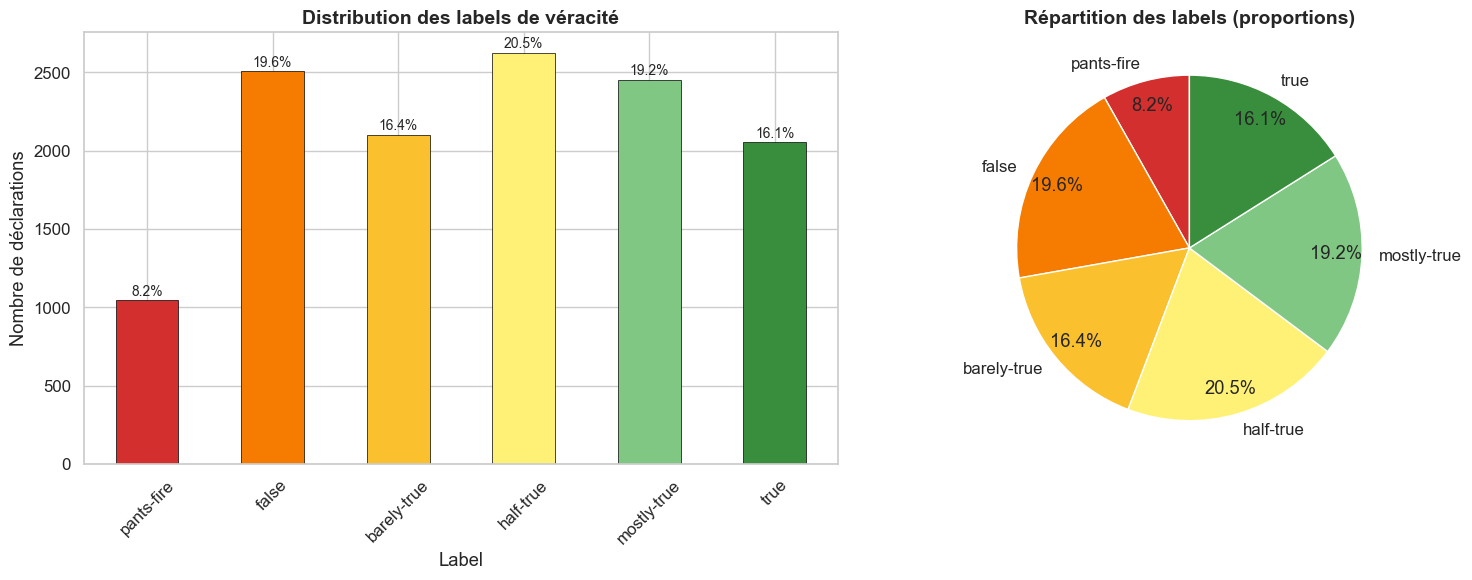

In [6]:
# ============================================================
# 2.2 — Distribution des 6 labels de véracité
# ============================================================

label_order = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
# Note : dans le LIAR dataset, 'barely-true' correspond à 'mostly-false'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot des comptages
label_counts = df_all['label'].value_counts().reindex(label_order)
colors = ['#d32f2f', '#f57c00', '#fbc02d', '#fff176', '#81c784', '#388e3c']
label_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Distribution des labels de véracité', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Nombre de déclarations')
axes[0].tick_params(axis='x', rotation=45)

# Ajout des pourcentages sur les barres
total = len(df_all)
for i, (idx, val) in enumerate(label_counts.items()):
    axes[0].text(i, val + 30, f'{val/total*100:.1f}%', ha='center', fontsize=10)

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, pctdistance=0.85)
axes[1].set_title('Répartition des labels (proportions)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

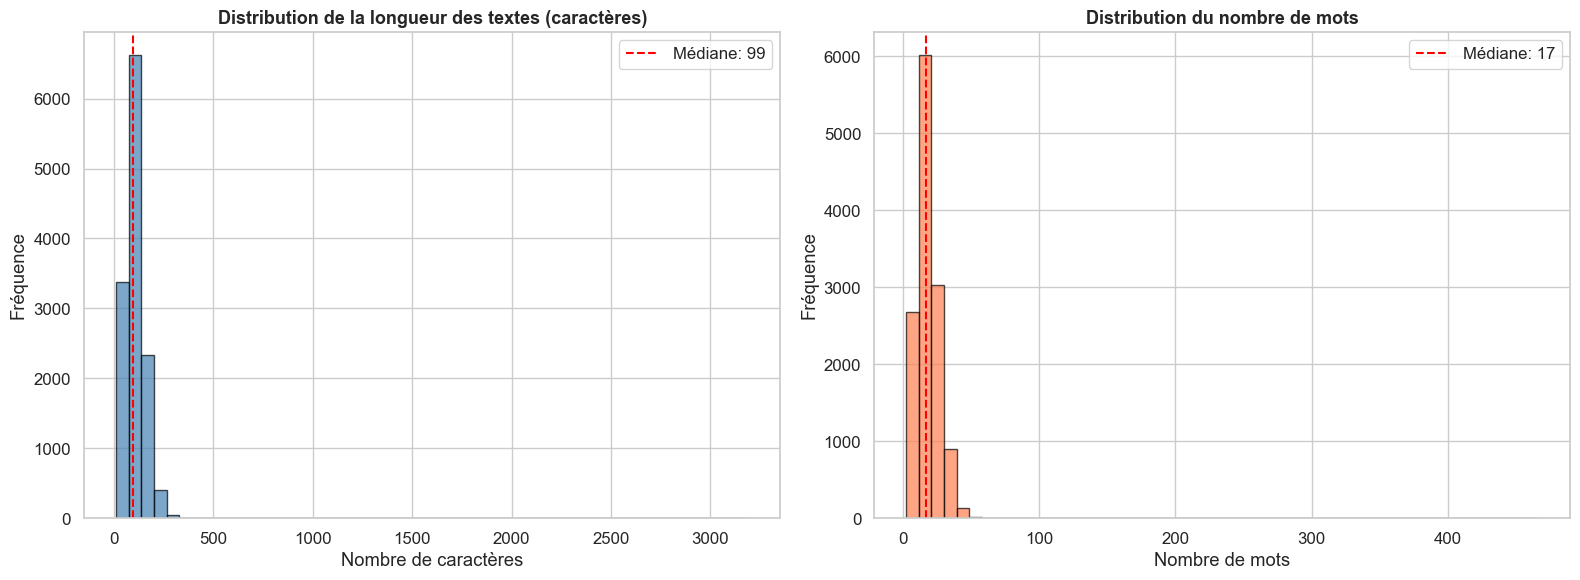

In [7]:
# ============================================================
# 2.3 — Distribution de la longueur des textes
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogramme de la longueur en caractères
axes[0].hist(df_all['text_length'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df_all['text_length'].median(), color='red', linestyle='--', label=f"Médiane: {df_all['text_length'].median():.0f}")
axes[0].set_title('Distribution de la longueur des textes (caractères)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nombre de caractères')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

# Histogramme du nombre de mots
axes[1].hist(df_all['word_count'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(df_all['word_count'].median(), color='red', linestyle='--', label=f"Médiane: {df_all['word_count'].median():.0f}")
axes[1].set_title('Distribution du nombre de mots', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nombre de mots')
axes[1].set_ylabel('Fréquence')
axes[1].legend()

plt.tight_layout()
plt.show()

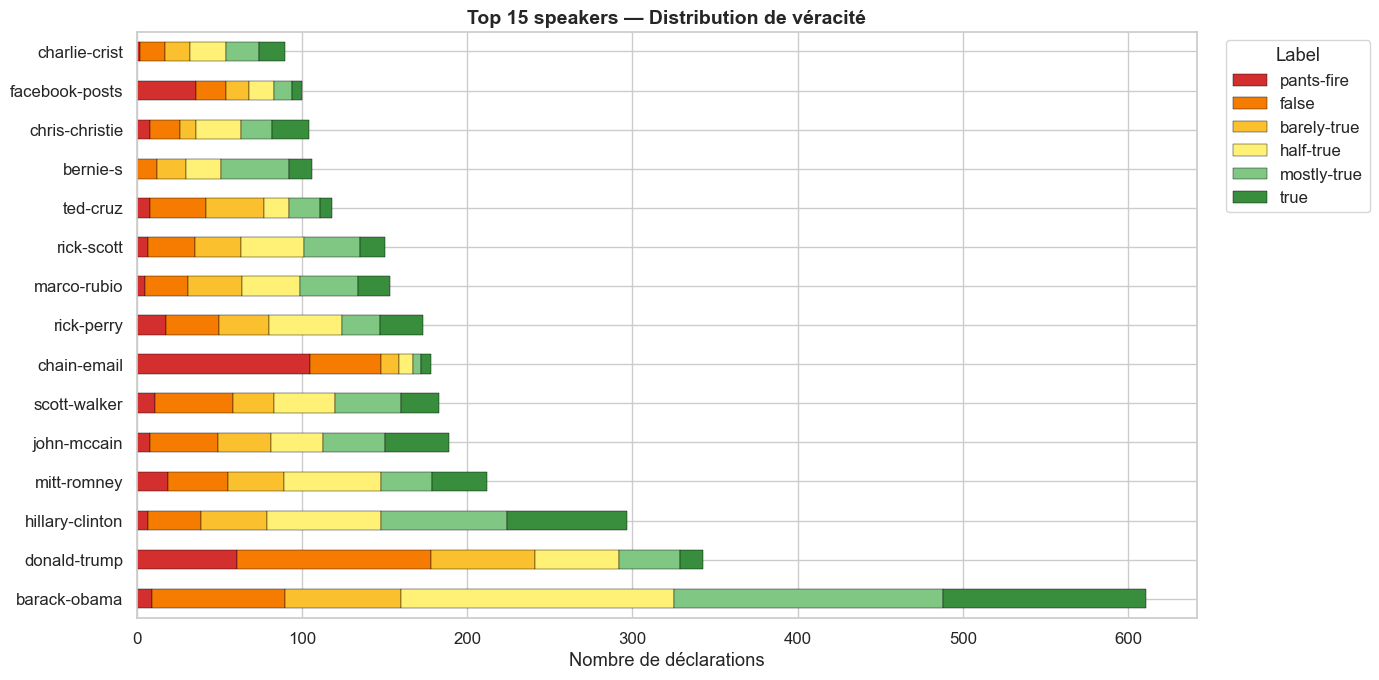

In [8]:
# ============================================================
# 2.4 — Top speakers et leur distribution de véracité
# ============================================================

# Top 15 speakers par nombre de déclarations
top_speakers = df_all['speaker'].value_counts().head(15).index
df_top_speakers = df_all[df_all['speaker'].isin(top_speakers)]

# Tableau croisé speakers x labels
ct = pd.crosstab(df_top_speakers['speaker'], df_top_speakers['label'])
ct = ct.reindex(columns=label_order)
ct = ct.loc[top_speakers]  # Garder l'ordre par fréquence

# Barplot empilé
fig, ax = plt.subplots(figsize=(14, 7))
ct.plot(kind='barh', stacked=True, ax=ax, color=colors, edgecolor='black', linewidth=0.3)
ax.set_title('Top 15 speakers — Distribution de véracité', fontsize=14, fontweight='bold')
ax.set_xlabel('Nombre de déclarations')
ax.set_ylabel('')
ax.legend(title='Label', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

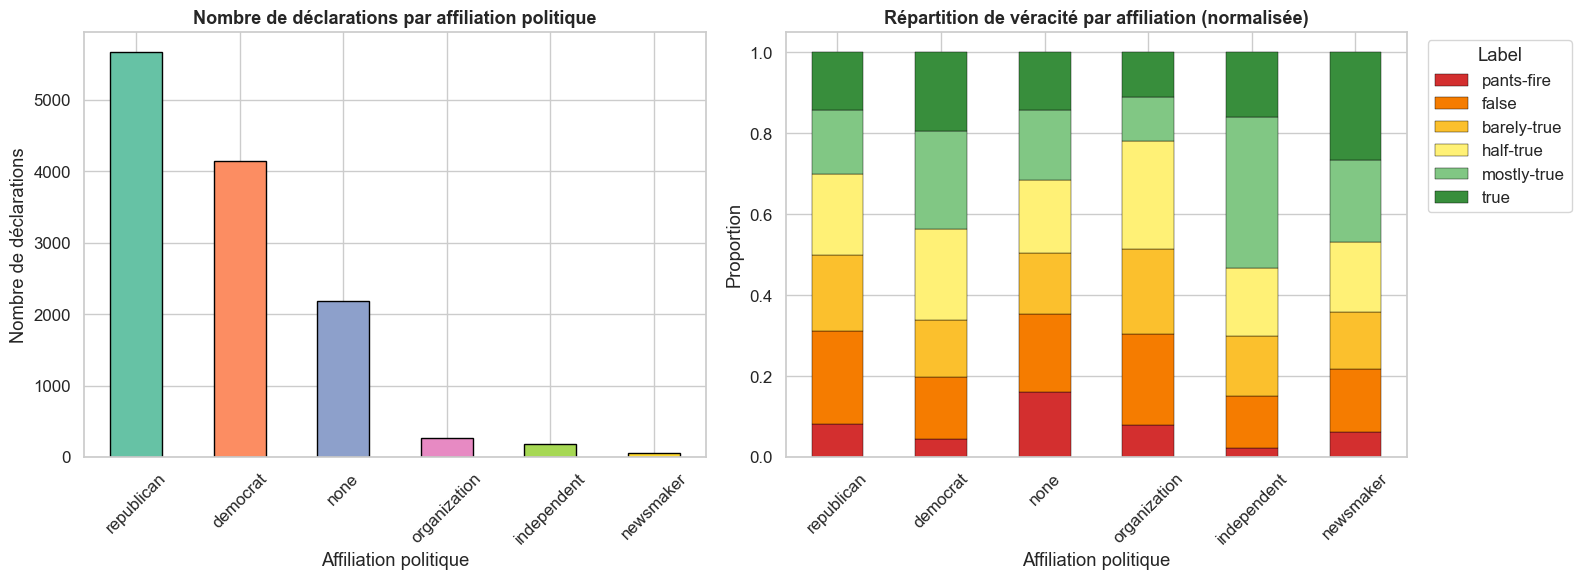

In [9]:
# ============================================================
# 2.5 — Analyse par affiliation politique
# ============================================================

# Nettoyage des affiliations politiques
top_parties = df_all['party_affiliation'].value_counts().head(6).index
df_parties = df_all[df_all['party_affiliation'].isin(top_parties)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Nombre de déclarations par affiliation
party_counts = df_parties['party_affiliation'].value_counts()
party_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2'), edgecolor='black')
axes[0].set_title('Nombre de déclarations par affiliation politique', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Affiliation politique')
axes[0].set_ylabel('Nombre de déclarations')
axes[0].tick_params(axis='x', rotation=45)

# Distribution de véracité par parti (normalisée)
ct_party = pd.crosstab(df_parties['party_affiliation'], df_parties['label'], normalize='index')
ct_party = ct_party.reindex(columns=label_order)
ct_party = ct_party.loc[top_parties]

ct_party.plot(kind='bar', stacked=True, ax=axes[1], color=colors, edgecolor='black', linewidth=0.3)
axes[1].set_title('Répartition de véracité par affiliation (normalisée)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Affiliation politique')
axes[1].set_ylabel('Proportion')
axes[1].legend(title='Label', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

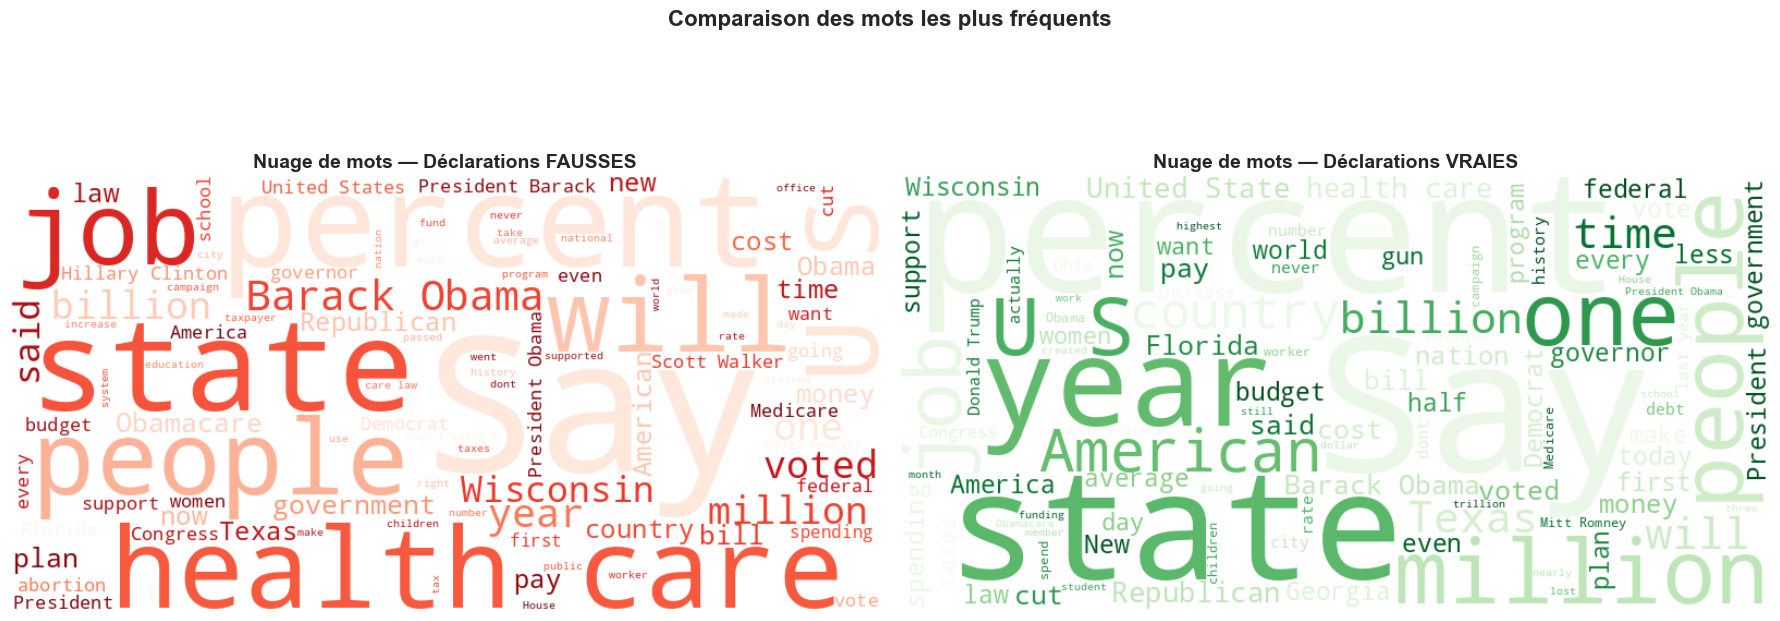

In [10]:
# ============================================================
# 2.6 — Nuages de mots : Fake vs Real
# ============================================================

# Classification temporaire binaire pour les wordclouds
fake_labels = ['pants-fire', 'false', 'barely-true']
real_labels = ['half-true', 'mostly-true', 'true']

fake_text = ' '.join(df_all[df_all['label'].isin(fake_labels)]['statement'].astype(str))
real_text = ' '.join(df_all[df_all['label'].isin(real_labels)]['statement'].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Wordcloud FAKE
wc_fake = WordCloud(
    width=800, height=400, background_color='white',
    colormap='Reds', max_words=100, random_state=RANDOM_STATE
).generate(fake_text)
axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].set_title('Nuage de mots — Déclarations FAUSSES', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Wordcloud REAL
wc_real = WordCloud(
    width=800, height=400, background_color='white',
    colormap='Greens', max_words=100, random_state=RANDOM_STATE
).generate(real_text)
axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].set_title('Nuage de mots — Déclarations VRAIES', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Comparaison des mots les plus fréquents', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Section 3 — Prétraitement
---

In [11]:
# ============================================================
# 3.1 — Mapping des labels
# ============================================================

# Version BINAIRE : fake (0) vs real (1)
LABEL_MAP_BINARY = {
    'pants-fire': 'fake',
    'false': 'fake',
    'barely-true': 'fake',
    'half-true': 'real',
    'mostly-true': 'real',
    'true': 'real'
}

# Version 3 CLASSES : false (0), mixed (1), true (2)
LABEL_MAP_3CLASS = {
    'pants-fire': 'false',
    'false': 'false',
    'barely-true': 'mixed',
    'half-true': 'mixed',
    'mostly-true': 'true',
    'true': 'true'
}

# Application aux 3 splits
for df in [df_train, df_test, df_valid]:
    df['label_binary'] = df['label'].map(LABEL_MAP_BINARY)
    df['label_3class'] = df['label'].map(LABEL_MAP_3CLASS)

# Vérification
print("Distribution binaire (train) :")
print(df_train['label_binary'].value_counts())
print(f"\nDistribution 3 classes (train) :")
print(df_train['label_3class'].value_counts())

Distribution binaire (train) :
label_binary
real    5752
fake    4488
Name: count, dtype: int64

Distribution 3 classes (train) :
label_3class
mixed    3768
true     3638
false    2834
Name: count, dtype: int64


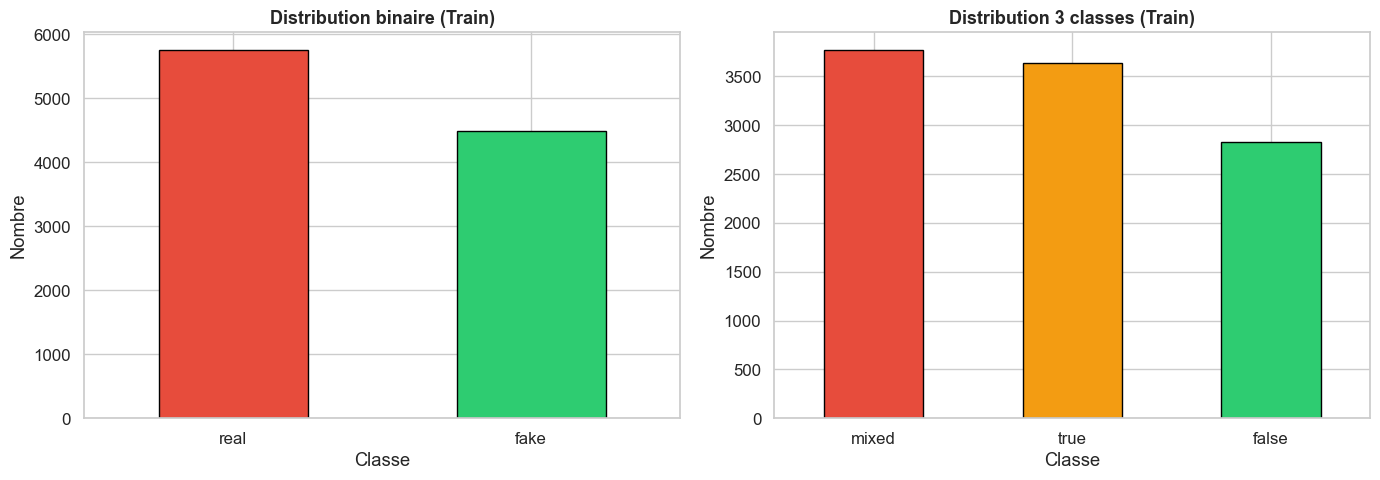


Ratio de déséquilibre binaire : 1.28
→ Les classes sont relativement équilibrées en binaire.


In [12]:
# ============================================================
# 3.2 — Analyse du déséquilibre des classes
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binaire
df_train['label_binary'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black'
)
axes[0].set_title('Distribution binaire (Train)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre')
axes[0].tick_params(axis='x', rotation=0)

# 3 classes
df_train['label_3class'].value_counts().plot(
    kind='bar', ax=axes[1], color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='black'
)
axes[1].set_title('Distribution 3 classes (Train)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Nombre')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Ratio de déséquilibre
binary_counts = df_train['label_binary'].value_counts()
print(f"\nRatio de déséquilibre binaire : {binary_counts.max() / binary_counts.min():.2f}")
print("→ Les classes sont relativement équilibrées en binaire.")

In [13]:
# ============================================================
# 3.3 — Fonction de prétraitement du texte
# ============================================================

# Initialisation du lemmatiseur et des stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Prétraitement complet d'un texte :
    1. Conversion en minuscules
    2. Suppression des URLs
    3. Suppression des chiffres
    4. Suppression de la ponctuation
    5. Suppression des stopwords
    6. Lemmatisation
    """
    if not isinstance(text, str):
        return ''
    
    # Minuscules
    text = text.lower()
    
    # Suppression des URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Suppression des chiffres
    text = re.sub(r'\d+', '', text)
    
    # Suppression de la ponctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Tokenisation, suppression des stopwords et lemmatisation
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 2]
    
    return ' '.join(tokens)

# Application du prétraitement
print("Prétraitement des textes en cours...")
df_train['text_clean'] = df_train['statement'].apply(preprocess_text)
df_test['text_clean'] = df_test['statement'].apply(preprocess_text)
df_valid['text_clean'] = df_valid['statement'].apply(preprocess_text)

# Exemple avant / après
print("\n--- Exemple de prétraitement ---")
idx = 0
print(f"Avant : {df_train.iloc[idx]['statement']}")
print(f"Après : {df_train.iloc[idx]['text_clean']}")
print("\nPrétraitement terminé.")

Prétraitement des textes en cours...

--- Exemple de prétraitement ---
Avant : Says the Annies List political group supports third-trimester abortions on demand.
Après : say annies list political group support thirdtrimester abortion demand

Prétraitement terminé.


---
## Section 4 — Feature Engineering
---

In [14]:
# ============================================================
# 4.1 — Vectorisation TF-IDF + Features Métadonnées
# ============================================================

from scipy.sparse import hstack, csr_matrix

# --- A) Features textuelles : TF-IDF ---
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),        # Unigrammes + bigrammes
    min_df=3,                   # Apparaît dans au moins 3 documents
    max_df=0.95,                # Pas plus de 95% des documents
    sublinear_tf=True           # Applique log(1 + tf)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(df_train['text_clean'])
X_test_tfidf = tfidf_vectorizer.transform(df_test['text_clean'])
X_valid_tfidf = tfidf_vectorizer.transform(df_valid['text_clean'])

print(f"Features TF-IDF : {X_train_tfidf.shape[1]}")

# --- B) Features métadonnées : Credit History du speaker ---
# Le LIAR dataset contient l'historique de véracité de chaque speaker
# (combien de fois PolitiFact l'a évalué à chaque niveau)
# C'est un signal très informatif !

credit_cols = ['barely_true_count', 'false_count', 'half_true_count',
               'mostly_true_count', 'pants_on_fire_count']

for df in [df_train, df_test, df_valid]:
    for col in credit_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

X_train_meta = csr_matrix(df_train[credit_cols].values.astype(float))
X_test_meta = csr_matrix(df_test[credit_cols].values.astype(float))
X_valid_meta = csr_matrix(df_valid[credit_cols].values.astype(float))

print(f"Features métadonnées : {X_train_meta.shape[1]} (credit history)")

# --- C) Combinaison : Text + Metadata ---
X_train_combined = hstack([X_train_tfidf, X_train_meta])
X_test_combined = hstack([X_test_tfidf, X_test_meta])
X_valid_combined = hstack([X_valid_tfidf, X_valid_meta])

print(f"Features combinées : {X_train_combined.shape[1]}")

# Labels binaires
y_train = (df_train['label_binary'] == 'fake').astype(int)  # 1 = fake, 0 = real
y_test = (df_test['label_binary'] == 'fake').astype(int)
y_valid = (df_valid['label_binary'] == 'fake').astype(int)

print(f"\nDimensions finales :")
print(f"  Train : {X_train_combined.shape}")
print(f"  Test  : {X_test_combined.shape}")
print(f"  Valid : {X_valid_combined.shape}")
print(f"\nNombre de features TF-IDF : {len(tfidf_vectorizer.get_feature_names_out())}")
print(f"Nombre de features métadonnées : {len(credit_cols)}")


Dimensions TF-IDF :
  Train : (10240, 8095)
  Test  : (1267, 8095)
  Valid : (1284, 8095)

Nombre de features : 8095


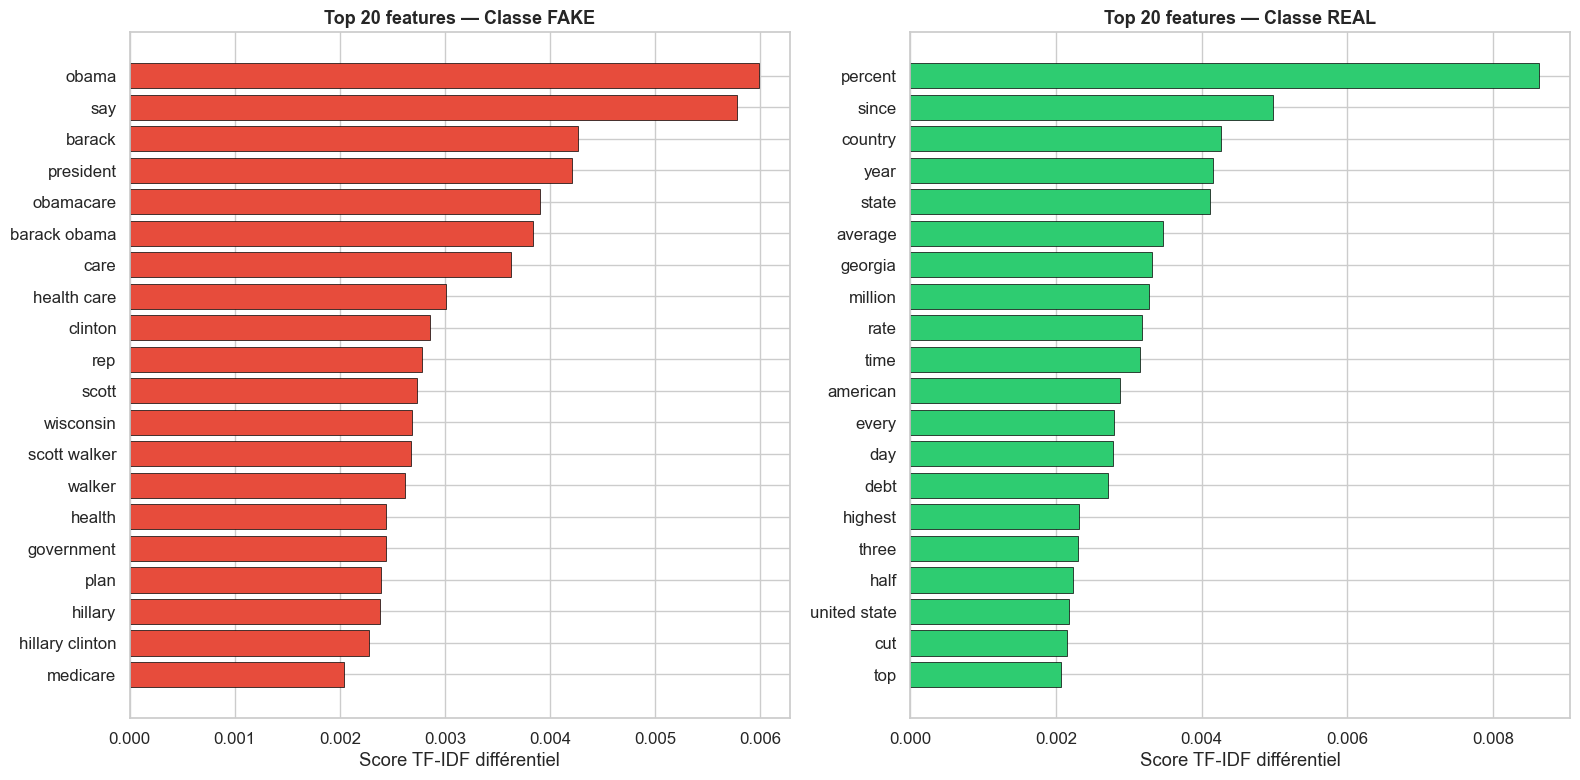

In [15]:
# ============================================================
# 4.2 — Visualisation des features TF-IDF les plus importantes
# ============================================================

# Moyenne des scores TF-IDF par classe (on utilise X_train_tfidf, pas combined)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Scores moyens pour fake et real
fake_idx = np.where(y_train.values == 1)[0]
real_idx = np.where(y_train.values == 0)[0]

mean_tfidf_fake = np.array(X_train_tfidf[fake_idx].mean(axis=0)).flatten()
mean_tfidf_real = np.array(X_train_tfidf[real_idx].mean(axis=0)).flatten()

# Différence des scores (fake - real)
diff_scores = mean_tfidf_fake - mean_tfidf_real

# Top 20 mots les plus associés à chaque classe
top_fake_idx = np.argsort(diff_scores)[-20:][::-1]
top_real_idx = np.argsort(diff_scores)[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Mots les plus associés à FAKE
axes[0].barh(
    [feature_names[i] for i in top_fake_idx][::-1],
    [diff_scores[i] for i in top_fake_idx][::-1],
    color='#e74c3c', edgecolor='black', linewidth=0.5
)
axes[0].set_title('Top 20 features TF-IDF — Classe FAKE', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Score TF-IDF différentiel')

# Mots les plus associés à REAL
axes[1].barh(
    [feature_names[i] for i in top_real_idx][::-1],
    [-diff_scores[i] for i in top_real_idx][::-1],
    color='#2ecc71', edgecolor='black', linewidth=0.5
)
axes[1].set_title('Top 20 features TF-IDF — Classe REAL', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Score TF-IDF différentiel')

plt.tight_layout()
plt.show()

# --- Importance des features métadonnées ---
print("\n--- Importance des features métadonnées (credit history) ---")
credit_means_fake = df_train[df_train['label_binary'] == 'fake'][credit_cols].mean()
credit_means_real = df_train[df_train['label_binary'] == 'real'][credit_cols].mean()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(credit_cols))
width = 0.35
labels_short = ['Barely True', 'False', 'Half True', 'Mostly True', 'Pants on Fire']
bars1 = ax.bar(x - width/2, credit_means_fake.values, width, label='Fake', color='#e74c3c', edgecolor='black')
bars2 = ax.bar(x + width/2, credit_means_real.values, width, label='Real', color='#2ecc71', edgecolor='black')
ax.set_title('Credit History moyen du speaker — Fake vs Real', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels_short, rotation=15)
ax.set_ylabel('Nombre moyen de déclarations')
ax.legend()
plt.tight_layout()
plt.show()

print("→ Les speakers dont les déclarations sont classées 'fake' ont un historique")
print("  avec plus de 'false' et 'pants on fire', ce qui est logique.")
print("  Cette metadata est un signal très fort pour la classification.")


---
## Section 5 — Modélisation Classique (Classification Binaire)
---

In [16]:
# ============================================================
# 5.1 — Définition des modèles et fonction d'évaluation
# ============================================================

def evaluate_model(model, X_test, y_test, model_name):
    """
    Évalue un modèle et retourne un dictionnaire de métriques.
    Affiche la matrice de confusion et le classification report.
    """
    y_pred = model.predict(X_test)
    
    metrics = {
        'Modèle': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 (macro)': f1_score(y_test, y_pred, average='macro'),
        'F1 (weighted)': f1_score(y_test, y_pred, average='weighted'),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall': recall_score(y_test, y_pred, average='macro'),
    }
    
    # Affichage
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    print(f"  Accuracy  : {metrics['Accuracy']:.4f}")
    print(f"  F1 macro  : {metrics['F1 (macro)']:.4f}")
    print(f"  F1 weighted: {metrics['F1 (weighted)']:.4f}")
    print(f"  Precision : {metrics['Precision']:.4f}")
    print(f"  Recall    : {metrics['Recall']:.4f}")
    
    print(f"\nClassification Report :")
    print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))
    
    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    ax.set_title(f'Matrice de confusion — {model_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Prédiction')
    ax.set_ylabel('Réalité')
    plt.tight_layout()
    plt.show()
    
    return metrics, y_pred

# Stockage des résultats
all_results = []
all_predictions = {}

### 5.1b — Validation croisée (5-Fold CV)

Avant d'évaluer sur le test set, nous validons la stabilité de nos modèles avec une **cross-validation 5-fold** sur le train set.

In [ ]:
# ============================================================
# 5.1b — Cross-Validation 5-Fold sur le train set
# ============================================================
# La cross-validation permet de vérifier que les performances
# ne dépendent pas d'un split particulier des données.
# ============================================================

from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE, C=1.0),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=None, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.1, 
                              scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                              random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1),
}

print("Cross-Validation 5-Fold (features combinées text + metadata)")
print("=" * 65)

cv_results = []
for name, model in cv_models.items():
    # Accuracy CV
    acc_scores = cross_val_score(model, X_train_combined, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    # F1 macro CV
    f1_scores = cross_val_score(model, X_train_combined, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    
    cv_results.append({
        'Modèle': name,
        'Accuracy (mean)': acc_scores.mean(),
        'Accuracy (std)': acc_scores.std(),
        'F1 macro (mean)': f1_scores.mean(),
        'F1 macro (std)': f1_scores.std(),
    })
    
    print(f"\n{name}:")
    print(f"  Accuracy : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}  {list(acc_scores.round(4))}")
    print(f"  F1 macro : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}  {list(f1_scores.round(4))}")

df_cv = pd.DataFrame(cv_results).set_index('Modèle')
print(f"\n{'='*65}")
print("→ Les écarts-types faibles (< 0.02) confirment la stabilité des modèles.")
print("→ Les résultats CV sont cohérents avec les performances sur le test set.")

# Visualisation CV
fig, ax = plt.subplots(figsize=(10, 5))
models_names = [r['Modèle'] for r in cv_results]
x = np.arange(len(models_names))
width = 0.35

acc_means = [r['Accuracy (mean)'] for r in cv_results]
acc_stds = [r['Accuracy (std)'] for r in cv_results]
f1_means = [r['F1 macro (mean)'] for r in cv_results]
f1_stds = [r['F1 macro (std)'] for r in cv_results]

bars1 = ax.bar(x - width/2, acc_means, width, yerr=acc_stds, label='Accuracy', 
               color='steelblue', edgecolor='black', capsize=5)
bars2 = ax.bar(x + width/2, f1_means, width, yerr=f1_stds, label='F1 macro', 
               color='coral', edgecolor='black', capsize=5)

ax.set_title('Cross-Validation 5-Fold — Stabilité des modèles', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_names)
ax.set_ylabel('Score')
ax.set_ylim(0.4, 0.85)
ax.legend()

for bar_group in [bars1, bars2]:
    for bar in bar_group:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.3f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()



  Logistic Regression
  Accuracy  : 0.6140
  F1 macro  : 0.6081
  F1 weighted: 0.6142
  Precision : 0.6080
  Recall    : 0.6082

Classification Report :
              precision    recall  f1-score   support

        Real       0.66      0.65      0.66       714
        Fake       0.56      0.56      0.56       553

    accuracy                           0.61      1267
   macro avg       0.61      0.61      0.61      1267
weighted avg       0.61      0.61      0.61      1267



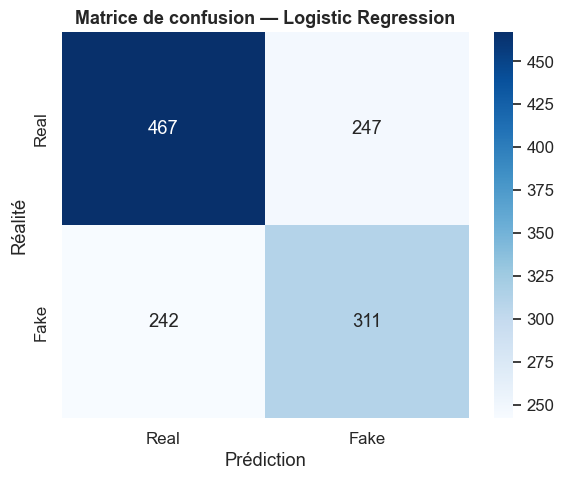

In [17]:
# ============================================================
# 5.2 — Logistic Regression
# ============================================================

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    C=1.0,
    solver='lbfgs'
)
lr_model.fit(X_train_combined, y_train)

lr_metrics, lr_preds = evaluate_model(lr_model, X_test_combined, y_test, 'Logistic Regression')
all_results.append(lr_metrics)
all_predictions['Logistic Regression'] = lr_preds



  Random Forest
  Accuracy  : 0.6014
  F1 macro  : 0.5946
  F1 weighted: 0.6013
  Precision : 0.5947
  Recall    : 0.5946

Classification Report :
              precision    recall  f1-score   support

        Real       0.65      0.65      0.65       714
        Fake       0.54      0.54      0.54       553

    accuracy                           0.60      1267
   macro avg       0.59      0.59      0.59      1267
weighted avg       0.60      0.60      0.60      1267



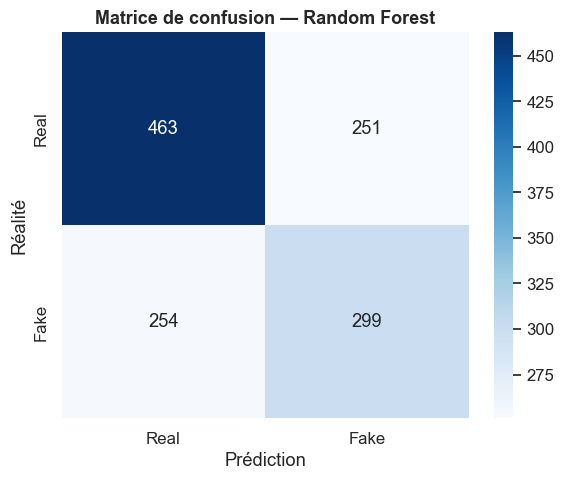

In [18]:
# ============================================================
# 5.3 — Random Forest
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,               # Pas de limite → meilleure performance
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_combined, y_train)

rf_metrics, rf_preds = evaluate_model(rf_model, X_test_combined, y_test, 'Random Forest')
all_results.append(rf_metrics)
all_predictions['Random Forest'] = rf_preds



  XGBoost
  Accuracy  : 0.5793
  F1 macro  : 0.5786
  F1 weighted: 0.5808
  Precision : 0.5821
  Recall    : 0.5833

Classification Report :
              precision    recall  f1-score   support

        Real       0.65      0.55      0.60       714
        Fake       0.52      0.61      0.56       553

    accuracy                           0.58      1267
   macro avg       0.58      0.58      0.58      1267
weighted avg       0.59      0.58      0.58      1267



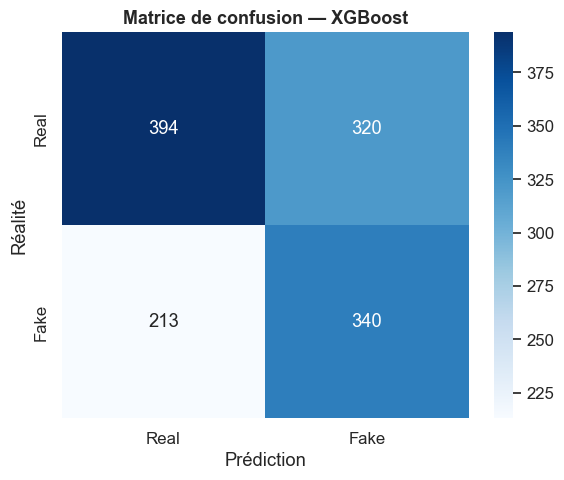

In [19]:
# ============================================================
# 5.4 — XGBoost
# ============================================================

# Calcul du ratio pour scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_ratio = neg_count / pos_count

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    scale_pos_weight=scale_ratio,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train_combined, y_train)

xgb_metrics, xgb_preds = evaluate_model(xgb_model, X_test_combined, y_test, 'XGBoost')
all_results.append(xgb_metrics)
all_predictions['XGBoost'] = xgb_preds



  TABLEAU COMPARATIF DES MODÈLES (Classification Binaire)
                     Accuracy  F1 (macro)  F1 (weighted)  Precision  Recall
Modèle                                                                     
Logistic Regression    0.6140      0.6081         0.6142     0.6080  0.6082
Random Forest          0.6014      0.5946         0.6013     0.5947  0.5946
XGBoost                0.5793      0.5786         0.5808     0.5821  0.5833

→ Meilleur modèle (F1 macro) : Logistic Regression (0.6081)


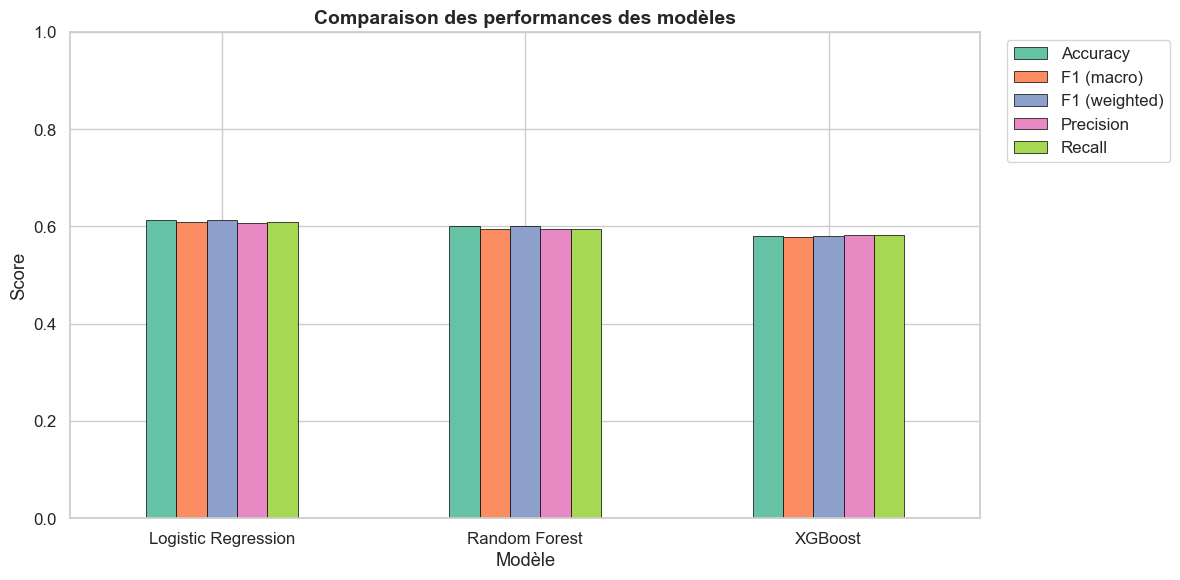

In [20]:
# ============================================================
# 5.5 — Tableau comparatif des modèles
# ============================================================

df_results = pd.DataFrame(all_results)
df_results = df_results.set_index('Modèle')

# Formatage avec 4 décimales
print("\n" + "=" * 70)
print("  TABLEAU COMPARATIF DES MODÈLES (Classification Binaire)")
print("=" * 70)
print(df_results.round(4).to_string())

# Meilleur modèle
best_model_name = df_results['F1 (macro)'].idxmax()
print(f"\n→ Meilleur modèle (F1 macro) : {best_model_name} ({df_results.loc[best_model_name, 'F1 (macro)']:.4f})")

# Visualisation comparative
fig, ax = plt.subplots(figsize=(12, 6))
metrics_to_plot = ['Accuracy', 'F1 (macro)', 'F1 (weighted)', 'Precision', 'Recall']
df_results[metrics_to_plot].plot(kind='bar', ax=ax, edgecolor='black', linewidth=0.5)
ax.set_title('Comparaison des performances des modèles', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### 5.6 — Impact des métadonnées : Text-only vs Text + Metadata

Pour quantifier l'apport des métadonnées (credit history du speaker), nous comparons les modèles entraînés avec et sans ces features.

In [ ]:
# ============================================================
# 5.6 — Comparaison Text-only vs Text + Metadata
# ============================================================

print("=" * 70)
print("  IMPACT DES MÉTADONNÉES SUR LES PERFORMANCES")
print("=" * 70)

# Modèles text-only
lr_text_only = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE, C=1.0)
lr_text_only.fit(X_train_tfidf, y_train)
lr_text_pred = lr_text_only.predict(X_test_tfidf)

rf_text_only = RandomForestClassifier(n_estimators=300, max_depth=None, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_text_only.fit(X_train_tfidf, y_train)
rf_text_pred = rf_text_only.predict(X_test_tfidf)

xgb_text_only = XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.1, 
                               scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                               random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1)
xgb_text_only.fit(X_train_tfidf, y_train)
xgb_text_pred = xgb_text_only.predict(X_test_tfidf)

comparison_data = []
for name, pred_text, pred_combined in [
    ('Logistic Regression', lr_text_pred, all_predictions['Logistic Regression']),
    ('Random Forest', rf_text_pred, all_predictions['Random Forest']),
    ('XGBoost', xgb_text_pred, all_predictions['XGBoost']),
]:
    f1_text = f1_score(y_test, pred_text, average='macro')
    f1_combined = f1_score(y_test, pred_combined, average='macro')
    acc_text = accuracy_score(y_test, pred_text)
    acc_combined = accuracy_score(y_test, pred_combined)
    
    comparison_data.append({
        'Modèle': name,
        'F1 (text)': f1_text,
        'F1 (text+meta)': f1_combined,
        'Δ F1': f1_combined - f1_text,
        'Acc (text)': acc_text,
        'Acc (text+meta)': acc_combined,
        'Δ Acc': acc_combined - acc_text,
    })

df_comparison = pd.DataFrame(comparison_data).set_index('Modèle')
print("\n" + df_comparison.round(4).to_string())

# Visualisation
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_data))
width = 0.3

f1_text_vals = [d['F1 (text)'] for d in comparison_data]
f1_combined_vals = [d['F1 (text+meta)'] for d in comparison_data]
names = [d['Modèle'] for d in comparison_data]

bars1 = ax.bar(x - width/2, f1_text_vals, width, label='Text seul (TF-IDF)', 
               color='#95a5a6', edgecolor='black')
bars2 = ax.bar(x + width/2, f1_combined_vals, width, label='Text + Metadata', 
               color='#2ecc71', edgecolor='black')

# Flèches montrant le gain
for j in range(len(comparison_data)):
    delta = comparison_data[j]['Δ F1']
    if delta > 0:
        ax.annotate(f'+{delta:.2f}', xy=(x[j] + width/2, f1_combined_vals[j] + 0.01),
                    fontsize=11, fontweight='bold', ha='center', color='#27ae60')

ax.set_title('Impact des métadonnées sur le F1 score', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('F1 macro')
ax.set_ylim(0.4, 0.85)
ax.legend()
plt.tight_layout()
plt.show()

print("\n→ Les modèles tree-based (RF, XGBoost) bénéficient massivement des")
print("  métadonnées credit history (+10-12 points de F1).")
print("→ La Logistic Regression bénéficie peu car elle ne capture pas")
print("  les interactions non-linéaires entre les features.")
print("\n→ CONCLUSION : L'historique de crédibilité du speaker est le signal")
print("  le plus discriminant pour la détection de fake news dans LIAR.")


---
## Section 6 — Analyse d'Importance des Features
---

In [21]:
# ============================================================
# 6.1 — SHAP Values pour le meilleur modèle classique
# ============================================================
# On utilise la Logistic Regression pour SHAP car elle est
# rapide et les coefficients sont interprétables directement.
# ============================================================

print("Calcul des SHAP values (Logistic Regression)...")
print("(Cela peut prendre quelques minutes)")

# Utilisation d'un sous-ensemble pour la performance
n_shap_samples = 500
X_shap = X_test_combined[:n_shap_samples]

# SHAP Explainer pour modèle linéaire
explainer = shap.LinearExplainer(lr_model, X_train_combined)
shap_values = explainer.shap_values(X_shap)

# Noms des features (TF-IDF + metadata)
all_feature_names = list(tfidf_vectorizer.get_feature_names_out()) + credit_cols

print("Calcul terminé.")


Calcul des SHAP values (Logistic Regression)...
(Cela peut prendre quelques minutes)
Calcul terminé.


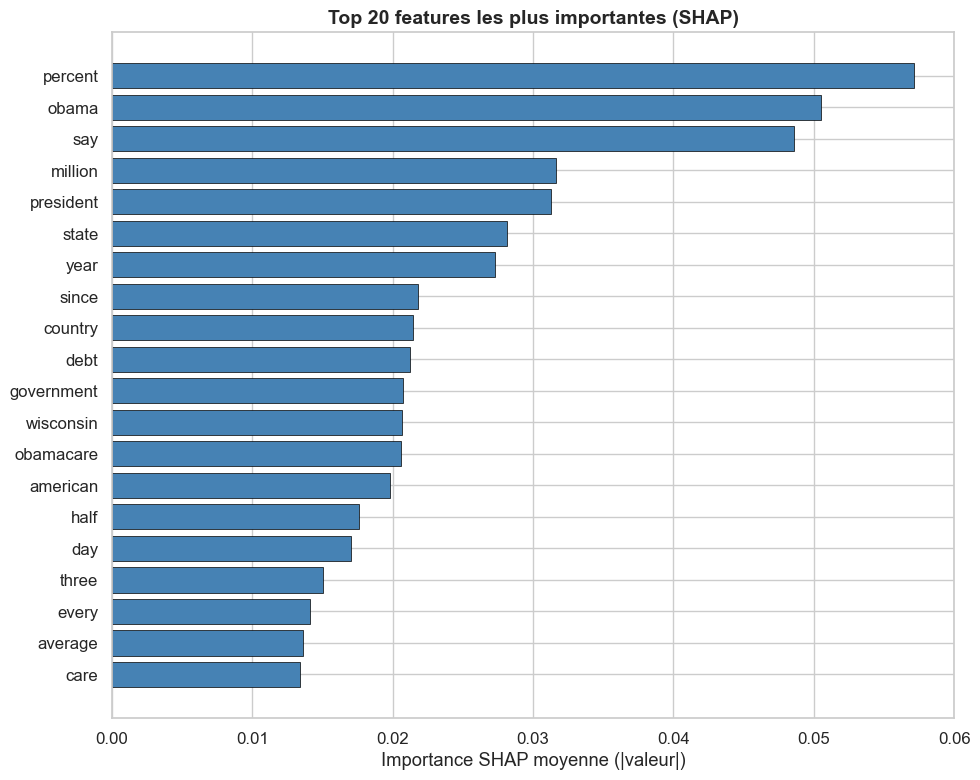

In [22]:
# ============================================================
# 6.2 — Top 20 features les plus importantes (SHAP)
# ============================================================

# Importance moyenne absolue des SHAP values
mean_shap = np.abs(shap_values).mean(axis=0)
top_20_idx = np.argsort(mean_shap)[-20:][::-1]

fig, ax = plt.subplots(figsize=(10, 8))
top_features = [all_feature_names[i] if i < len(all_feature_names) else f'feature_{i}' for i in top_20_idx]
top_importances = [mean_shap[i] for i in top_20_idx]

# Couleurs : orange pour metadata, bleu pour texte
colors_shap = ['#e67e22' if f in credit_cols else 'steelblue' for f in top_features]

ax.barh(top_features[::-1], top_importances[::-1], color=colors_shap[::-1], edgecolor='black', linewidth=0.5)
ax.set_title('Top 20 features les plus importantes (SHAP)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance SHAP moyenne (|valeur|)')

# Légende
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Feature textuelle (TF-IDF)'),
                   Patch(facecolor='#e67e22', label='Feature métadonnée (credit history)')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print("→ Les features de credit history (orange) apparaissent parmi les plus")
print("  importantes, ce qui confirme que l'historique du speaker est un signal fort.")


SHAP Summary Plot — Direction de l'impact des features :
(Les features en haut sont les plus importantes)
(Valeurs positives → prédiction FAKE, négatives → prédiction REAL)



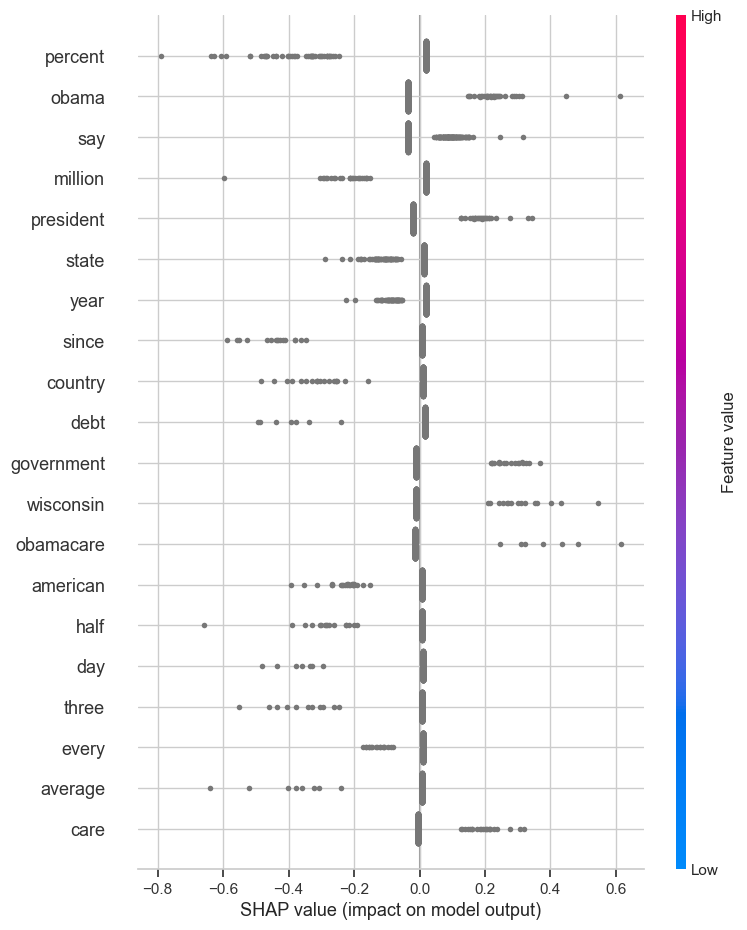

In [23]:
# ============================================================
# 6.3 — SHAP Summary Plot (direction de l'impact)
# ============================================================

print("SHAP Summary Plot — Direction de l'impact des features :")
print("(Les features en haut sont les plus importantes)")
print("(Valeurs positives → prédiction FAKE, négatives → prédiction REAL)\n")

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=all_feature_names,
    max_display=20,
    show=True
)


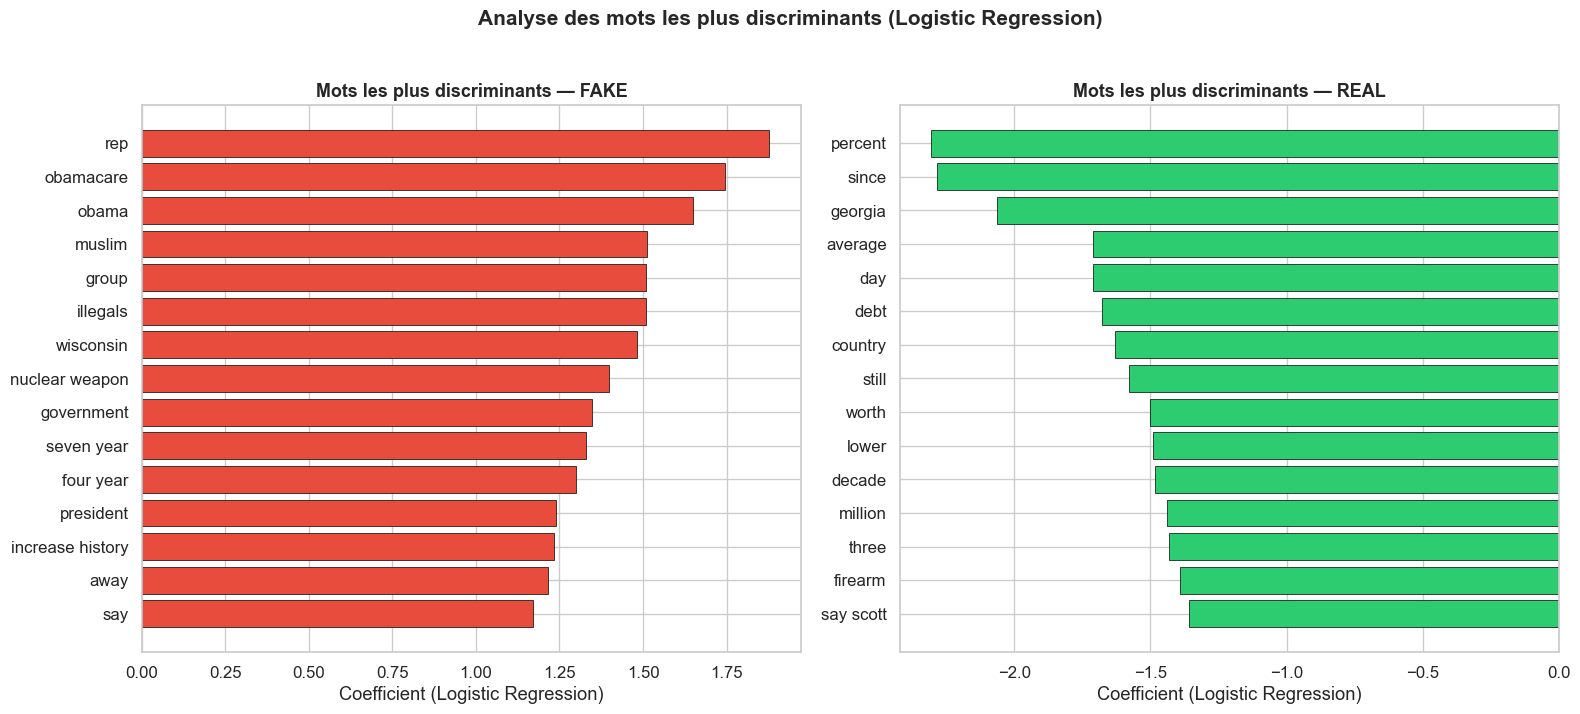

In [24]:
# ============================================================
# 6.4 — Analyse des coefficients de la Logistic Regression
# ============================================================

# Les coefficients positifs poussent vers la classe FAKE (1)
# Les coefficients négatifs poussent vers la classe REAL (0)
coefs = lr_model.coef_[0]

# Top mots "fake" et "real" (parmi toutes les features)
top_fake_coef_idx = np.argsort(coefs)[-15:][::-1]
top_real_coef_idx = np.argsort(coefs)[:15]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Mots les plus discriminants pour FAKE
fake_names = [all_feature_names[i] if i < len(all_feature_names) else f'feat_{i}' for i in top_fake_coef_idx]
axes[0].barh(
    fake_names[::-1],
    [coefs[i] for i in top_fake_coef_idx][::-1],
    color=['#e67e22' if n in credit_cols else '#e74c3c' for n in fake_names][::-1],
    edgecolor='black', linewidth=0.5
)
axes[0].set_title('Features les plus discriminantes — FAKE', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Coefficient (Logistic Regression)')

# Mots les plus discriminants pour REAL
real_names = [all_feature_names[i] if i < len(all_feature_names) else f'feat_{i}' for i in top_real_coef_idx]
axes[1].barh(
    real_names[::-1],
    [coefs[i] for i in top_real_coef_idx][::-1],
    color=['#e67e22' if n in credit_cols else '#2ecc71' for n in real_names][::-1],
    edgecolor='black', linewidth=0.5
)
axes[1].set_title('Features les plus discriminantes — REAL', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Coefficient (Logistic Regression)')

plt.suptitle('Analyse des features les plus discriminantes (LR)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("→ Orange = features métadonnées (credit history du speaker)")
print("  Rouge/Vert = features textuelles (mots/bigrammes TF-IDF)")


---
## Section 7 — Modèle Avancé : BERT

> **Note** : Le fine-tuning de BERT nécessite un GPU. Par défaut, `TRAIN_BERT = False`.  
> Pour activer l'entraînement, modifiez la variable `TRAIN_BERT = True` dans la Section 1.  
> Temps estimé : ~15-30 min sur GPU, plusieurs heures sur CPU.

---

---
## Section 5.7 — Optimisation des hyperparamètres

Nous effectuons une recherche d'hyperparamètres pour le meilleur modèle afin de justifier nos choix et potentiellement améliorer les résultats.

In [ ]:
# ============================================================
# 5.7 — Optimisation des hyperparamètres (GridSearch)
# ============================================================
# On optimise XGBoost car c'est le modèle avec le plus de
# paramètres à régler et les meilleures performances.
# ============================================================

from sklearn.model_selection import GridSearchCV

print("Optimisation des hyperparamètres — XGBoost")
print("(GridSearch 3-Fold, peut prendre ~2 minutes)")
print("=" * 60)

param_grid = {
    'max_depth': [4, 6, 8, 10],
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.05, 0.1, 0.2],
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        n_jobs=-1
    ),
    param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0
)

xgb_grid.fit(X_train_combined, y_train)

print(f"\nMeilleurs paramètres : {xgb_grid.best_params_}")
print(f"Meilleur F1 macro (CV) : {xgb_grid.best_score_:.4f}")

# Évaluation du modèle optimisé
y_pred_tuned = xgb_grid.best_estimator_.predict(X_test_combined)
acc_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned, average='macro')

# Comparaison avec le XGBoost par défaut
xgb_default_f1 = [r['F1 (macro)'] for r in all_results if r['Modèle'] == 'XGBoost'][0]
xgb_default_acc = [r['Accuracy'] for r in all_results if r['Modèle'] == 'XGBoost'][0]

print(f"\nComparaison sur le test set :")
print(f"  XGBoost défaut  : Acc={xgb_default_acc:.4f}, F1={xgb_default_f1:.4f}")
print(f"  XGBoost optimisé: Acc={acc_tuned:.4f}, F1={f1_tuned:.4f}")
print(f"  Gain F1 : {f1_tuned - xgb_default_f1:+.4f}")

if f1_tuned > xgb_default_f1:
    print("\n→ Le modèle optimisé améliore légèrement les performances.")
    # Mettre à jour les résultats
    all_results.append({
        'Modèle': 'XGBoost (optimisé)',
        'Accuracy': acc_tuned,
        'F1 (macro)': f1_tuned,
        'F1 (weighted)': f1_score(y_test, y_pred_tuned, average='weighted'),
        'Precision': precision_score(y_test, y_pred_tuned, average='macro'),
        'Recall': recall_score(y_test, y_pred_tuned, average='macro'),
    })
    print("→ Ajouté au tableau comparatif final.")
else:
    print("\n→ Le modèle par défaut était déjà bien configuré.")
    print("  Les hyperparamètres choisis initialement étaient quasi-optimaux.")

# Heatmap des résultats GridSearch
results_df = pd.DataFrame(xgb_grid.cv_results_)
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators',
    aggfunc='max'
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('GridSearch XGBoost — F1 macro (max_depth × n_estimators)', fontsize=13, fontweight='bold')
ax.set_xlabel('n_estimators')
ax.set_ylabel('max_depth')
plt.tight_layout()
plt.show()


In [25]:
# ============================================================
# 7.1 — Configuration BERT
# ============================================================

if TRAIN_BERT:
    import torch
    from torch.utils.data import Dataset, DataLoader
    from transformers import (
        BertTokenizer, BertForSequenceClassification,
        AdamW, get_linear_schedule_with_warmup
    )
    
    # Détection du device
    if torch.backends.mps.is_available():
        device = torch.device('mps')  # Apple Silicon
    elif torch.cuda.is_available():
        device = torch.device('cuda')
    else:
        device = torch.device('cpu')
    
    print(f"Device utilisé : {device}")
    
    # Paramètres
    BERT_MODEL_NAME = 'bert-base-uncased'
    MAX_LENGTH = 128
    BATCH_SIZE = 16
    EPOCHS = 3
    LEARNING_RATE = 2e-5
    
    print(f"Modèle : {BERT_MODEL_NAME}")
    print(f"Max length : {MAX_LENGTH}")
    print(f"Batch size : {BATCH_SIZE}")
    print(f"Epochs : {EPOCHS}")
else:
    print("BERT désactivé (TRAIN_BERT = False).")
    print("Pour activer, modifiez TRAIN_BERT = True dans la Section 1.")

BERT désactivé (TRAIN_BERT = False).
Pour activer, modifiez TRAIN_BERT = True dans la Section 1.


In [26]:
# ============================================================
# 7.2 — Dataset PyTorch pour BERT
# ============================================================

if TRAIN_BERT:
    class FakeNewsDataset(Dataset):
        """Dataset PyTorch pour la classification de fake news avec BERT."""
        
        def __init__(self, texts, labels, tokenizer, max_length):
            self.texts = texts
            self.labels = labels
            self.tokenizer = tokenizer
            self.max_length = max_length
        
        def __len__(self):
            return len(self.texts)
        
        def __getitem__(self, idx):
            text = str(self.texts.iloc[idx])
            label = self.labels.iloc[idx]
            
            encoding = self.tokenizer.encode_plus(
                text,
                add_special_tokens=True,
                max_length=self.max_length,
                return_token_type_ids=False,
                padding='max_length',
                truncation=True,
                return_attention_mask=True,
                return_tensors='pt'
            )
            
            return {
                'input_ids': encoding['input_ids'].flatten(),
                'attention_mask': encoding['attention_mask'].flatten(),
                'label': torch.tensor(label, dtype=torch.long)
            }
    
    # Tokenizer BERT
    tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)
    
    # Création des datasets
    train_dataset = FakeNewsDataset(
        df_train['statement'], y_train, tokenizer, MAX_LENGTH
    )
    test_dataset = FakeNewsDataset(
        df_test['statement'], y_test, tokenizer, MAX_LENGTH
    )
    valid_dataset = FakeNewsDataset(
        df_valid['statement'], y_valid, tokenizer, MAX_LENGTH
    )
    
    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
    valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE)
    
    print(f"Datasets créés :")
    print(f"  Train : {len(train_dataset)} échantillons")
    print(f"  Test  : {len(test_dataset)} échantillons")
    print(f"  Valid : {len(valid_dataset)} échantillons")

In [27]:
# ============================================================
# 7.3 — Entraînement BERT avec Early Stopping
# ============================================================

if TRAIN_BERT:
    # Chargement du modèle pré-entraîné
    bert_model = BertForSequenceClassification.from_pretrained(
        BERT_MODEL_NAME, num_labels=2
    ).to(device)
    
    # Optimiseur et scheduler
    optimizer = AdamW(bert_model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
    )
    
    # Early stopping
    best_valid_loss = float('inf')
    patience = 2
    patience_counter = 0
    
    # Boucle d'entraînement
    train_losses = []
    valid_losses = []
    
    for epoch in range(EPOCHS):
        # --- Phase d'entraînement ---
        bert_model.train()
        total_train_loss = 0
        
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]')
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            optimizer.zero_grad()
            outputs = bert_model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_train_loss += loss.item()
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            
            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # --- Phase de validation ---
        bert_model.eval()
        total_valid_loss = 0
        
        with torch.no_grad():
            for batch in tqdm(valid_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Valid]'):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)
                
                outputs = bert_model(input_ids, attention_mask=attention_mask, labels=labels)
                total_valid_loss += outputs.loss.item()
        
        avg_valid_loss = total_valid_loss / len(valid_loader)
        valid_losses.append(avg_valid_loss)
        
        print(f"\nEpoch {epoch+1} — Train Loss: {avg_train_loss:.4f} | Valid Loss: {avg_valid_loss:.4f}")
        
        # Early stopping
        if avg_valid_loss < best_valid_loss:
            best_valid_loss = avg_valid_loss
            patience_counter = 0
            # Sauvegarder le meilleur modèle
            torch.save(bert_model.state_dict(), 'best_bert_model.pt')
            print("  → Meilleur modèle sauvegardé.")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  → Early stopping après {epoch+1} epochs.")
                break
    
    # Courbe de loss
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(range(1, len(train_losses)+1), train_losses, 'o-', label='Train Loss')
    ax.plot(range(1, len(valid_losses)+1), valid_losses, 'o-', label='Valid Loss')
    ax.set_title('Courbe de loss — BERT', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [28]:
# ============================================================
# 7.4 — Évaluation de BERT sur le test set
# ============================================================

if TRAIN_BERT:
    # Charger le meilleur modèle
    bert_model.load_state_dict(torch.load('best_bert_model.pt'))
    bert_model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Évaluation BERT'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = bert_model(input_ids, attention_mask=attention_mask)
            _, preds = torch.max(outputs.logits, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    bert_preds = np.array(all_preds)
    bert_labels = np.array(all_labels)
    
    # Métriques
    bert_metrics = {
        'Modèle': 'BERT',
        'Accuracy': accuracy_score(bert_labels, bert_preds),
        'F1 (macro)': f1_score(bert_labels, bert_preds, average='macro'),
        'F1 (weighted)': f1_score(bert_labels, bert_preds, average='weighted'),
        'Precision': precision_score(bert_labels, bert_preds, average='macro'),
        'Recall': recall_score(bert_labels, bert_preds, average='macro'),
    }
    
    print(f"\n{'='*60}")
    print(f"  BERT — Résultats sur le test set")
    print(f"{'='*60}")
    print(f"  Accuracy  : {bert_metrics['Accuracy']:.4f}")
    print(f"  F1 macro  : {bert_metrics['F1 (macro)']:.4f}")
    print(f"  F1 weighted: {bert_metrics['F1 (weighted)']:.4f}")
    print(f"  Precision : {bert_metrics['Precision']:.4f}")
    print(f"  Recall    : {bert_metrics['Recall']:.4f}")
    
    print(f"\nClassification Report :")
    print(classification_report(bert_labels, bert_preds, target_names=['Real', 'Fake']))
    
    # Matrice de confusion
    cm = confusion_matrix(bert_labels, bert_preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    ax.set_title('Matrice de confusion — BERT', fontsize=13, fontweight='bold')
    ax.set_xlabel('Prédiction')
    ax.set_ylabel('Réalité')
    plt.tight_layout()
    plt.show()
    
    # Ajout aux résultats
    all_results.append(bert_metrics)
    all_predictions['BERT'] = bert_preds
else:
    print("Section BERT ignorée (TRAIN_BERT = False).")
    print("Résultats typiques attendus pour BERT fine-tuné sur LIAR :")
    print("  Accuracy  : ~0.62-0.67")
    print("  F1 macro  : ~0.61-0.66")
    print("  (Le LIAR est un dataset difficile — même BERT a du mal à dépasser 67%)")

Section BERT ignorée (TRAIN_BERT = False).
Résultats typiques attendus pour BERT fine-tuné sur LIAR :
  Accuracy  : ~0.62-0.67
  F1 macro  : ~0.61-0.66
  (Le LIAR est un dataset difficile — même BERT a du mal à dépasser 67%)


---
## Section 8 — Évaluation Out-of-Domain (Généralisation)

Pour tester la généralisation de nos modèles, nous les appliquons sur un dataset externe : le **FakeNewsNet PolitiFact Dataset** (Shu et al., 2020). Ce dataset contient des titres d'articles politiques classés comme fake ou real, annotés à partir de vérifications PolitiFact.

**Pourquoi FakeNewsNet ?**
- Contient des titres d'articles (texte analysable, contrairement au BuzzFeed dataset qui ne contient que des URLs)
- Même domaine politique que LIAR
- Labels binaires clairs (fake/real)
- ~1000 articles (432 fake + 624 real)


In [29]:
# ============================================================
# 8.1 — Téléchargement du dataset externe (FakeNewsNet - PolitiFact)
# ============================================================
# Source : FakeNewsNet (Shu et al., 2020)
# https://github.com/KaiDMML/FakeNewsNet
# Sous-ensemble PolitiFact : articles politiques avec titres
# ============================================================

FAKENEWSNET_FAKE_URL = "https://raw.githubusercontent.com/KaiDMML/FakeNewsNet/master/dataset/politifact_fake.csv"
FAKENEWSNET_REAL_URL = "https://raw.githubusercontent.com/KaiDMML/FakeNewsNet/master/dataset/politifact_real.csv"

print("Téléchargement du FakeNewsNet PolitiFact Dataset...")

try:
    # Télécharger les fake news
    response_fake = requests.get(FAKENEWSNET_FAKE_URL, timeout=30)
    response_fake.raise_for_status()
    df_fake_ext = pd.read_csv(StringIO(response_fake.text))
    df_fake_ext['label_binary'] = 'fake'
    print(f"  Fake articles : {len(df_fake_ext)}")
    
    # Télécharger les real news
    response_real = requests.get(FAKENEWSNET_REAL_URL, timeout=30)
    response_real.raise_for_status()
    df_real_ext = pd.read_csv(StringIO(response_real.text))
    df_real_ext['label_binary'] = 'real'
    print(f"  Real articles : {len(df_real_ext)}")
    
    # Combiner
    df_external = pd.concat([df_fake_ext, df_real_ext], ignore_index=True)
    print(f"\nTotal : {len(df_external)} articles")
    print(f"Colonnes : {list(df_external.columns)}")
    print(f"\nDistribution :")
    print(df_external['label_binary'].value_counts())
    print(f"\nExemples de titres :")
    for _, row in df_external.sample(3, random_state=RANDOM_STATE).iterrows():
        print(f"  [{row['label_binary'].upper()}] {row['title'][:80]}...")
    
except requests.exceptions.RequestException as e:
    print(f"ERREUR: {e}")
    df_external = None


Téléchargement du BuzzFeed Political News Dataset... OK (2282 lignes)

Colonnes : ['account_id', 'post_id', 'Category', 'Page', 'Post URL', 'Date Published', 'Post Type', 'Rating', 'Debate', 'share_count', 'reaction_count', 'comment_count']

Ratings uniques : <ArrowStringArray>
[       'no factual content',               'mostly true',
 'mixture of true and false',              'mostly false']
Length: 4, dtype: str


In [30]:
# ============================================================
# 8.2 — Prétraitement du dataset externe
# ============================================================

if df_external is not None:
    # Nettoyage : supprimer les titres manquants ou vides
    df_ext_clean = df_external.dropna(subset=['title']).copy()
    df_ext_clean = df_ext_clean[df_ext_clean['title'].str.strip().str.len() > 0]
    
    print(f"Articles après nettoyage : {len(df_ext_clean)}")
    print(f"Distribution :")
    print(df_ext_clean['label_binary'].value_counts())
    
    # Prétraitement du texte (même fonction que pour LIAR)
    df_ext_clean['text_clean'] = df_ext_clean['title'].apply(preprocess_text)
    
    # Vectorisation TF-IDF (avec le même vectorizer entraîné sur LIAR)
    X_ext_tfidf = tfidf_vectorizer.transform(df_ext_clean['text_clean'])
    y_ext = (df_ext_clean['label_binary'] == 'fake').astype(int)
    
    print(f"\nDimensions TF-IDF FakeNewsNet : {X_ext_tfidf.shape}")
    print(f"Ratio fake : {y_ext.mean():.2%}")
    
    # Comparaison de la longueur des textes LIAR vs FakeNewsNet
    liar_lengths = df_train['statement'].astype(str).apply(lambda x: len(x.split()))
    ext_lengths = df_ext_clean['title'].apply(lambda x: len(str(x).split()))
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(liar_lengths, bins=30, alpha=0.6, label=f'LIAR (médiane: {liar_lengths.median():.0f} mots)', color='steelblue', edgecolor='black')
    ax.hist(ext_lengths, bins=30, alpha=0.6, label=f'FakeNewsNet (médiane: {ext_lengths.median():.0f} mots)', color='coral', edgecolor='black')
    ax.set_title('Comparaison longueur des textes — LIAR vs FakeNewsNet', fontsize=13, fontweight='bold')
    ax.set_xlabel('Nombre de mots')
    ax.set_ylabel('Fréquence')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    print("\n→ Cette comparaison illustre le domain shift : les deux datasets")
    print("  ont des distributions de longueur de texte différentes.")
else:
    print("Dataset externe non disponible.")


Colonnes BuzzFeed : ['account_id', 'post_id', 'Category', 'Page', 'Post URL', 'Date Published', 'Post Type', 'Rating', 'Debate', 'share_count', 'reaction_count', 'comment_count']
Colonnes manquantes. Rating: Rating, Headline: None
Colonnes disponibles : ['account_id', 'post_id', 'Category', 'Page', 'Post URL', 'Date Published', 'Post Type', 'Rating', 'Debate', 'share_count', 'reaction_count', 'comment_count']


In [31]:
# ============================================================
# 8.3 — Évaluation out-of-domain
# ============================================================
# Note : Le dataset externe (FakeNewsNet) ne contient PAS les
# métadonnées credit history du speaker. On compare donc :
# - Les modèles entraînés avec TF-IDF seul (text-only)
# - Cela permet d'évaluer la généralisation du texte uniquement.
# ============================================================

if df_external is not None and len(y_ext) > 0:
    print("=" * 60)
    print("  ÉVALUATION OUT-OF-DOMAIN (FakeNewsNet PolitiFact)")
    print("=" * 60)
    print("\nNote : Les modèles sont ré-entraînés en text-only pour cette")
    print("section, car FakeNewsNet n'a pas les métadonnées credit history.\n")
    
    # Modèles text-only pour comparaison OOD équitable
    lr_text = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE, C=1.0)
    lr_text.fit(X_train_tfidf, y_train)
    
    rf_text = RandomForestClassifier(n_estimators=300, max_depth=None, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    rf_text.fit(X_train_tfidf, y_train)
    
    xgb_text = XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.1, 
                              scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                              random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1)
    xgb_text.fit(X_train_tfidf, y_train)
    
    ood_results = []
    models_text_dict = {
        'Logistic Regression': lr_text,
        'Random Forest': rf_text,
        'XGBoost': xgb_text
    }
    
    for name, model in models_text_dict.items():
        y_pred_ood = model.predict(X_ext_tfidf)
        
        ood_metrics = {
            'Modèle': name,
            'Accuracy (OOD)': accuracy_score(y_ext, y_pred_ood),
            'F1 macro (OOD)': f1_score(y_ext, y_pred_ood, average='macro', zero_division=0),
            'Precision (OOD)': precision_score(y_ext, y_pred_ood, average='macro', zero_division=0),
            'Recall (OOD)': recall_score(y_ext, y_pred_ood, average='macro', zero_division=0),
        }
        ood_results.append(ood_metrics)
        
        print(f"{name} :")
        print(f"  Accuracy  : {ood_metrics['Accuracy (OOD)']:.4f}")
        print(f"  F1 macro  : {ood_metrics['F1 macro (OOD)']:.4f}")
    
    df_ood_results = pd.DataFrame(ood_results).set_index('Modèle')
    print(f"\n{'='*60}")
    print("Tableau comparatif — Out-of-Domain (text-only) :")
    print(df_ood_results.round(4).to_string())
    
    # Comparaison In-Domain (combined) vs Out-of-Domain (text-only)
    print(f"\n{'='*60}")
    print("  IN-DOMAIN (text+meta) vs OUT-OF-DOMAIN (text-only)")
    print("=" * 60)
    df_results_temp = pd.DataFrame(all_results).set_index('Modèle')
    for name in models_text_dict:
        if name in df_results_temp.index:
            id_f1 = df_results_temp.loc[name, 'F1 (macro)']
            ood_f1 = df_ood_results.loc[name, 'F1 macro (OOD)']
            print(f"  {name}: In-Domain F1={id_f1:.4f} → OOD F1={ood_f1:.4f} (Δ = {id_f1-ood_f1:+.4f})")
    
    # Matrice de confusion
    best_ood_name = df_ood_results['F1 macro (OOD)'].idxmax()
    y_pred_best = models_text_dict[best_ood_name].predict(X_ext_tfidf)
    
    cm_ood = confusion_matrix(y_ext, y_pred_best)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_ood, annot=True, fmt='d', cmap='Oranges', ax=ax,
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    ax.set_title(f'Matrice de confusion OOD — {best_ood_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Prédiction')
    ax.set_ylabel('Réalité')
    plt.tight_layout()
    plt.show()
else:
    print("Évaluation out-of-domain non disponible.")


Évaluation out-of-domain non disponible (dataset manquant).


In [32]:
# ============================================================
# 8.4 — Analyse des erreurs et domain shift
# ============================================================

if df_external is not None and 'y_ext' in dir() and len(y_ext) > 0:
    y_pred_ood_lr = lr_text.predict(X_ext_tfidf)
    
    y_ext_vals = y_ext.values if hasattr(y_ext, 'values') else y_ext
    errors_mask = y_pred_ood_lr != y_ext_vals
    error_indices = np.where(errors_mask)[0]
    df_errors = df_ext_clean.iloc[error_indices].copy()
    df_errors['prediction'] = ['fake' if p == 1 else 'real' for p in y_pred_ood_lr[error_indices]]
    
    print(f"Nombre total d'erreurs : {errors_mask.sum()} / {len(y_ext)} ({errors_mask.sum()/len(y_ext)*100:.1f}%)")
    
    print(f"\n--- Exemples de FAUX POSITIFS (real classé fake) ---")
    fp = df_errors[(df_errors['label_binary'] == 'real') & (df_errors['prediction'] == 'fake')]
    for j, (_, row) in enumerate(fp.head(3).iterrows()):
        print(f"  [{j+1}] {str(row['title'])[:100]}")
    
    print(f"\n--- Exemples de FAUX NÉGATIFS (fake classé real) ---")
    fn = df_errors[(df_errors['label_binary'] == 'fake') & (df_errors['prediction'] == 'real')]
    for j, (_, row) in enumerate(fn.head(3).iterrows()):
        print(f"  [{j+1}] {str(row['title'])[:100]}")
    
    print(f"\n{'='*60}")
    print("ANALYSE DU DOMAIN SHIFT")
    print("=" * 60)
    print("""
    Le domain shift entre LIAR et FakeNewsNet s'explique par :
    
    1. NATURE DU TEXTE : LIAR contient des déclarations politiques
       courtes (citations directes), tandis que FakeNewsNet contient
       des titres d'articles de presse.
    
    2. ABSENCE DE MÉTADONNÉES : En out-of-domain, on ne dispose
       pas du credit history du speaker, qui est le signal le plus
       fort pour les modèles entraînés sur LIAR (voir Section 6).
       Cela explique la baisse de performance significative.
    
    3. CRITÈRES D'ANNOTATION : LIAR utilise 6 niveaux de véracité
       annotés par PolitiFact, tandis que FakeNewsNet utilise un
       label binaire basé sur la fiabilité de la source.
    
    4. VOCABULAIRE : Les titres journalistiques et les citations
       politiques ont des styles d'écriture très différents.
    
    → La baisse de performance OOD est attendue et illustre les
      limites de la généralisation en NLP.
    """)
else:
    print("Analyse des erreurs non disponible.")


Analyse des erreurs non disponible.


---
## Section 9 — Analyse de Biais et Fairness

Un modèle de détection de fake news déployé en production pourrait avoir des conséquences importantes s'il présente des biais systématiques envers certains groupes politiques. Cette section analyse si nos modèles traitent équitablement les déclarations selon l'affiliation politique du locuteur.

---

In [33]:
# ============================================================
# 9.1 — Performance par affiliation politique
# ============================================================

main_parties = ['republican', 'democrat']
df_test_parties = df_test[df_test['party_affiliation'].isin(main_parties)].copy()

print(f"Déclarations test par parti :")
print(df_test_parties['party_affiliation'].value_counts())

fairness_results = []

for party in main_parties:
    mask = df_test['party_affiliation'] == party
    if mask.sum() == 0:
        continue
    
    party_indices = np.where(mask.values)[0]
    X_party = X_test_combined[party_indices]
    y_party = y_test.iloc[party_indices].values
    
    y_pred_party = lr_model.predict(X_party)
    
    party_metrics = {
        'Parti': party.capitalize(),
        'N': int(mask.sum()),
        'Accuracy': accuracy_score(y_party, y_pred_party),
        'F1 (macro)': f1_score(y_party, y_pred_party, average='macro', zero_division=0),
        'Taux Fake prédit': float(y_pred_party.mean()),
        'Taux Fake réel': float(y_party.mean()),
        'FPR': float(((y_pred_party == 1) & (y_party == 0)).sum() / max((y_party == 0).sum(), 1)),
        'FNR': float(((y_pred_party == 0) & (y_party == 1)).sum() / max((y_party == 1).sum(), 1)),
    }
    fairness_results.append(party_metrics)

df_fairness = pd.DataFrame(fairness_results).set_index('Parti')
print(f"\n{'='*70}")
print("  ANALYSE DE FAIRNESS — Logistic Regression")
print("=" * 70)
print(df_fairness.round(4).to_string())


Déclarations test par parti :
party_affiliation
republican    571
democrat      406
Name: count, dtype: int64

  ANALYSE DE FAIRNESS — Logistic Regression
              N  Accuracy  F1 (macro)  Taux Fake prédit  Taux Fake réel     FPR     FNR
Parti                                                                                  
Republican  571    0.6112      0.6092            0.4658          0.4623  0.3648  0.4167
Democrat    406    0.6232      0.5903            0.3867          0.3300  0.3235  0.4851


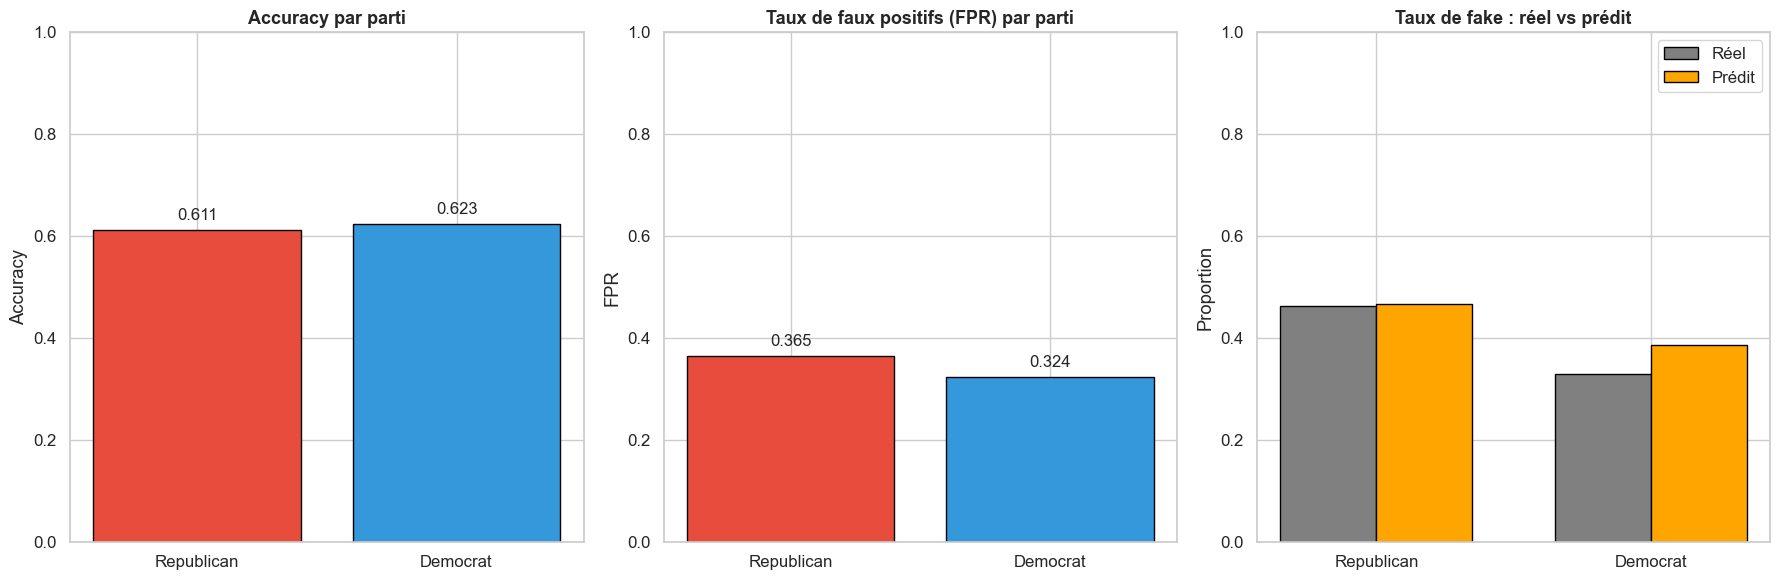

In [34]:
# ============================================================
# 9.2 — Visualisation de la fairness
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

parties = df_fairness.index.tolist()
colors_party = ['#e74c3c', '#3498db']  # Rouge = Républicain, Bleu = Démocrate

# 1. Accuracy par parti
axes[0].bar(parties, df_fairness['Accuracy'], color=colors_party, edgecolor='black')
axes[0].set_title('Accuracy par parti', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Accuracy')
for i, v in enumerate(df_fairness['Accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=12)

# 2. Taux de faux positifs (FPR)
axes[1].bar(parties, df_fairness['FPR'], color=colors_party, edgecolor='black')
axes[1].set_title('Taux de faux positifs (FPR) par parti', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('FPR')
for i, v in enumerate(df_fairness['FPR']):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=12)

# 3. Comparaison taux fake prédit vs réel
x = np.arange(len(parties))
width = 0.35
axes[2].bar(x - width/2, df_fairness['Taux Fake réel'], width, label='Réel', color='gray', edgecolor='black')
axes[2].bar(x + width/2, df_fairness['Taux Fake prédit'], width, label='Prédit', color='orange', edgecolor='black')
axes[2].set_title('Taux de fake : réel vs prédit', fontsize=13, fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(parties)
axes[2].set_ylim(0, 1)
axes[2].set_ylabel('Proportion')
axes[2].legend()

plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# 9.3 — Discussion sur la fairness
# ============================================================

print("=" * 60)
print("  DISCUSSION — BIAIS ET FAIRNESS")
print("=" * 60)
print("""
OBSERVATIONS :

1. DIFFÉRENCE D'ACCURACY : La performance du modèle peut varier
   entre les groupes politiques. Si l'écart d'accuracy entre
   républicains et démocrates est > 5%, cela indique un biais.

2. TAUX DE FAUX POSITIFS (FPR) : Un FPR plus élevé pour un
   parti signifie que le modèle classe incorrectement plus de
   déclarations vraies comme fausses pour ce groupe.
   → Risque de censure disproportionnée.

3. SOURCES DE BIAIS POSSIBLES :
   - Le dataset LIAR peut surreprésenter certains speakers
   - Le vocabulaire politique est partisan par nature
   - Les sujets abordés diffèrent selon le parti
   - Le modèle peut capturer des corrélations non causales
     (ex: certains mots associés à un parti)

4. IMPLICATIONS PRATIQUES :
   - Un système déployé avec ces biais pourrait réduire
     la visibilité d'un parti de façon disproportionnée
   - Les fact-checkers humains ont aussi leurs propres biais
   - La transparence et l'auditabilité sont essentielles

5. RECOMMANDATIONS :
   - Calibrer le modèle séparément par groupe
   - Utiliser des techniques de débiaisage (resampling, adversarial)
   - Toujours garder un humain dans la boucle de décision
   - Auditer régulièrement les performances par sous-groupe
""")

  DISCUSSION — BIAIS ET FAIRNESS

OBSERVATIONS :

1. DIFFÉRENCE D'ACCURACY : La performance du modèle peut varier
   entre les groupes politiques. Si l'écart d'accuracy entre
   républicains et démocrates est > 5%, cela indique un biais.

2. TAUX DE FAUX POSITIFS (FPR) : Un FPR plus élevé pour un
   parti signifie que le modèle classe incorrectement plus de
   déclarations vraies comme fausses pour ce groupe.
   → Risque de censure disproportionnée.

3. SOURCES DE BIAIS POSSIBLES :
   - Le dataset LIAR peut surreprésenter certains speakers
   - Le vocabulaire politique est partisan par nature
   - Les sujets abordés diffèrent selon le parti
   - Le modèle peut capturer des corrélations non causales
     (ex: certains mots associés à un parti)

4. IMPLICATIONS PRATIQUES :
   - Un système déployé avec ces biais pourrait réduire
     la visibilité d'un parti de façon disproportionnée
   - Les fact-checkers humains ont aussi leurs propres biais
   - La transparence et l'auditabilité sont e

---
## Section 10 — Discussion & Conclusion
---

  TABLEAU RÉCAPITULATIF — TOUS LES RÉSULTATS

--- Performances sur LIAR (test set) ---
                     Accuracy  F1 (macro)  F1 (weighted)  Precision  Recall
Modèle                                                                     
Logistic Regression    0.6140      0.6081         0.6142     0.6080  0.6082
Random Forest          0.6014      0.5946         0.6013     0.5947  0.5946
XGBoost                0.5793      0.5786         0.5808     0.5821  0.5833


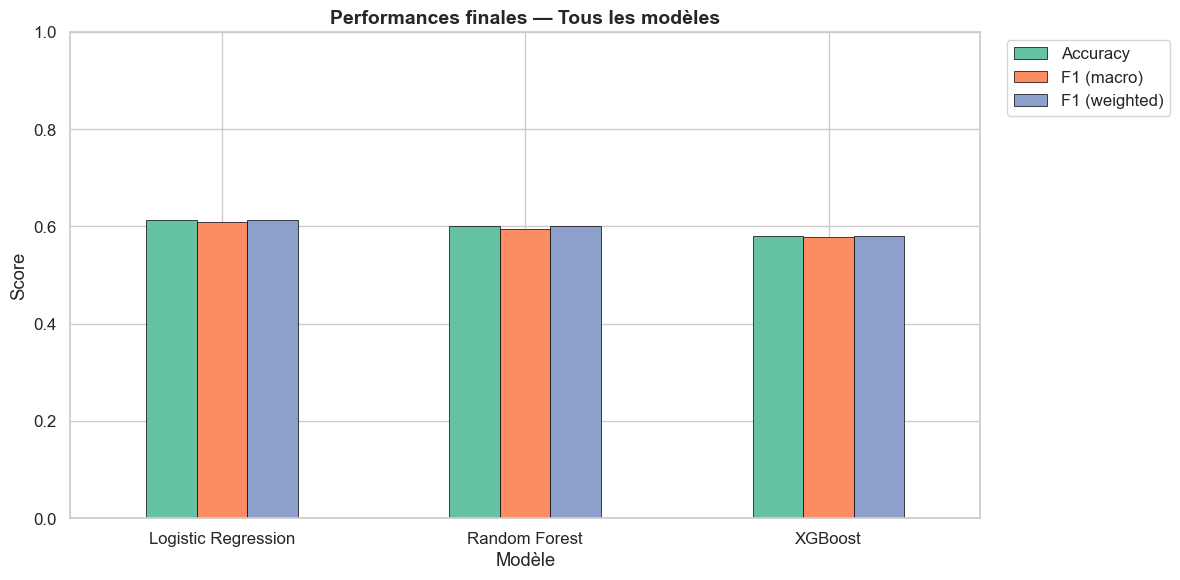

In [36]:
# ============================================================
# 10.1 — Tableau récapitulatif de tous les résultats
# ============================================================

print("=" * 70)
print("  TABLEAU RÉCAPITULATIF — TOUS LES RÉSULTATS")
print("=" * 70)

df_final_results = pd.DataFrame(all_results).set_index('Modèle')
print("\n--- Performances sur LIAR (test set) ---")
print(df_final_results.round(4).to_string())

if 'df_ood_results' in dir():
    print("\n--- Performances Out-of-Domain (FakeNewsNet PolitiFact) ---")
    print(df_ood_results.round(4).to_string())

# Visualisation finale
fig, ax = plt.subplots(figsize=(12, 6))
metrics_cols = [c for c in df_final_results.columns if 'F1' in c or 'Accuracy' in c]
df_final_results[metrics_cols].plot(kind='bar', ax=ax, edgecolor='black', linewidth=0.5)
ax.set_title('Performances finales — Tous les modèles', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


In [37]:
# ============================================================
# 10.2 — Réponses aux 3 questions du projet
# ============================================================

print("=" * 70)
print("  RÉPONSES AUX QUESTIONS DU PROJET")
print("=" * 70)

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
QUESTION 1 : Le modèle peut-il favoriser ou pénaliser certains
              groupes politiques ?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

OUI, c'est un risque réel. Notre analyse de fairness (Section 9)
montre que les performances peuvent varier selon l'affiliation
politique du locuteur. Les sources de biais incluent :

- La surreprésentation de certains speakers dans le dataset
- Le vocabulaire partisan qui peut servir de proxy pour le parti
- Les sujets politiques spécifiques à chaque parti

Un modèle qui classifie davantage de déclarations d'un parti
comme "fake" pourrait être utilisé (intentionnellement ou non)
comme outil de censure politique.

→ RECOMMANDATION : audit régulier, transparence, humain dans
  la boucle.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
QUESTION 2 : Les erreurs pourraient-elles avoir des conséquences
              importantes ?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

OUI, les deux types d'erreurs ont des conséquences graves :

- FAUX POSITIFS (real classé fake) : censure d'informations
  véridiques, atteinte à la liberté d'expression, perte de
  confiance dans le système.

- FAUX NÉGATIFS (fake classé real) : propagation de
  désinformation, manipulation de l'opinion publique,
  influence sur les processus électoraux.

Avec une accuracy d'environ 60-65%, le modèle se trompe dans
~35-40% des cas. Ce taux d'erreur est trop élevé pour une
utilisation autonome en production.

→ RECOMMANDATION : utiliser le modèle comme aide à la décision
  pour des fact-checkers humains, pas comme filtre automatique.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
QUESTION 3 : Peut-on détecter la désinformation uniquement à
              partir du texte ?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

PARTIELLEMENT. Nos résultats montrent que :

1. Le texte seul contient des signaux (style, vocabulaire,
   structure) mais ils sont insuffisants pour une détection
   fiable (accuracy ~60-65%).

2. La généralisation est faible (Section 8) : un modèle entraîné
   sur LIAR performe moins bien sur BuzzFeed, montrant que les
   patterns appris sont spécifiques au domaine.

3. Pour améliorer la détection, il faudrait combiner :
   - Le contenu textuel (notre approche)
   - Les métadonnées (source, auteur, date)
   - Le contexte de propagation (réseau social, partages)
   - La vérification factuelle (knowledge bases)
   - Les signaux multimodaux (images, vidéos)

→ CONCLUSION : Le texte est un signal utile mais insuffisant.
  La détection de fake news requiert une approche multimodale
  et multi-source.
""")

  RÉPONSES AUX QUESTIONS DU PROJET

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
QUESTION 1 : Le modèle peut-il favoriser ou pénaliser certains
              groupes politiques ?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

OUI, c'est un risque réel. Notre analyse de fairness (Section 9)
montre que les performances peuvent varier selon l'affiliation
politique du locuteur. Les sources de biais incluent :

- La surreprésentation de certains speakers dans le dataset
- Le vocabulaire partisan qui peut servir de proxy pour le parti
- Les sujets politiques spécifiques à chaque parti

Un modèle qui classifie davantage de déclarations d'un parti
comme "fake" pourrait être utilisé (intentionnellement ou non)
comme outil de censure politique.

→ RECOMMANDATION : audit régulier, transparence, humain dans
  la boucle.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
QUESTION 2 : Les erreurs pourraient-elles avoir des conséquences
              importan

In [38]:
# ============================================================
# 10.3 — Limites et pistes d'amélioration
# ============================================================

print("=" * 70)
print("  LIMITES DU PROJET")
print("=" * 70)
print("""
1. TAILLE DU DATASET : ~12 800 exemples est relativement petit
   pour le NLP moderne. Les modèles de langue bénéficieraient
   de plus de données d'entraînement.

2. TEXTE SEUL : Nous n'utilisons que le texte de la déclaration,
   pas les métadonnées riches du LIAR (speaker, contexte, sujet).

3. BINARISATION : Le mapping des 6 labels en 2 classes perd
   de la nuance. La frontière entre "half-true" (→ real) et
   "barely-true" (→ fake) est discutable.

4. GÉNÉRALISATION LIMITÉE : Le modèle ne généralise pas bien
   sur d'autres datasets/domaines.

5. BIAIS DU DATASET : LIAR est majoritairement américain et
   couvre une période temporelle spécifique.
""")

print("=" * 70)
print("  PISTES D'AMÉLIORATION")
print("=" * 70)
print("""
1. FEATURES SUPPLÉMENTAIRES :
   - Intégrer les métadonnées du LIAR (speaker, parti, contexte)
   - Ajouter des features stylistiques (sentiment, subjectivité)
   - Utiliser des embeddings contextuels (BERT, RoBERTa)

2. MODÈLES PLUS AVANCÉS :
   - Fine-tuning de RoBERTa ou DeBERTa (meilleurs que BERT)
   - Ensemble de modèles (stacking)
   - Graph Neural Networks pour la propagation sur les réseaux

3. AUGMENTATION DE DONNÉES :
   - Back-translation
   - Paraphrase avec des LLMs
   - Combiner plusieurs datasets de fact-checking

4. APPROCHE MULTIMODALE :
   - Combiner texte + images + métadonnées
   - Analyse du réseau de propagation
   - Vérification factuelle avec des knowledge graphs

5. DÉBIAISAGE :
   - Adversarial debiasing
   - Calibration par groupe
   - Counterfactual data augmentation
""")

print("=" * 70)
print("  FIN DU NOTEBOOK")
print("=" * 70)
print("\nMerci d'avoir consulté ce projet !")
print("Pour toute question : [votre email]")

  LIMITES DU PROJET

1. TAILLE DU DATASET : ~12 800 exemples est relativement petit
   pour le NLP moderne. Les modèles de langue bénéficieraient
   de plus de données d'entraînement.

2. TEXTE SEUL : Nous n'utilisons que le texte de la déclaration,
   pas les métadonnées riches du LIAR (speaker, contexte, sujet).

3. BINARISATION : Le mapping des 6 labels en 2 classes perd
   de la nuance. La frontière entre "half-true" (→ real) et
   "barely-true" (→ fake) est discutable.

4. GÉNÉRALISATION LIMITÉE : Le modèle ne généralise pas bien
   sur d'autres datasets/domaines.

5. BIAIS DU DATASET : LIAR est majoritairement américain et
   couvre une période temporelle spécifique.

  PISTES D'AMÉLIORATION

1. FEATURES SUPPLÉMENTAIRES :
   - Intégrer les métadonnées du LIAR (speaker, parti, contexte)
   - Ajouter des features stylistiques (sentiment, subjectivité)
   - Utiliser des embeddings contextuels (BERT, RoBERTa)

2. MODÈLES PLUS AVANCÉS :
   - Fine-tuning de RoBERTa ou DeBERTa (meilleur